In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [3]:
FILE_PATH     = '/Users/pbuabie/Desktop/MQU/Session 1 (2026)/BUSA8031/Group Project/NSW Price and Demand 20210701_20240630.xlsx'
OUTPUT_FOLDER = '/Users/pbuabie/Desktop/MQU/Session 1 (2026)/BUSA8031/Group Project'
FINANCIAL_YEAR = 'FY2023–24'

In [4]:
# LOAD & FILTER TO FY2023-24 
df = pd.read_excel(FILE_PATH)
 
# Rename columns to standard names
df = df.rename(columns={
    'NSW1_Price':  'RRP',
    'NSW1_Demand': 'TOTALDEMAND'
})
df = df.sort_values('SETTLEMENTDATE').reset_index(drop=True)
 
print(f"  Full dataset: {df['SETTLEMENTDATE'].min().date()} → {df['SETTLEMENTDATE'].max().date()}")
print(f"  Total rows: {len(df):,}")

# Filter to FY2023-24 only (July 2023 – June 2024)
df = df[
    (df['SETTLEMENTDATE'] >= '2023-07-01') &
    (df['SETTLEMENTDATE'] <  '2024-07-01')
].reset_index(drop=True)

print(f"  Filtered to {FINANCIAL_YEAR}: {len(df):,} rows")
print(f"  Date range: {df['SETTLEMENTDATE'].min().date()} → {df['SETTLEMENTDATE'].max().date()}")

  Full dataset: 2021-07-01 → 2024-06-30
  Total rows: 315,646
  Filtered to FY2023–24: 105,406 rows
  Date range: 2023-07-01 → 2024-06-30


In [5]:
# ADD HELPER COLUMNS 
df['date']      = df['SETTLEMENTDATE'].dt.date
df['month']     = df['SETTLEMENTDATE'].dt.month
df['time']      = df['SETTLEMENTDATE'].dt.strftime('%H:%M')
df['yearmonth'] = df['SETTLEMENTDATE'].dt.to_period('M')
 
season_map = {
    12:'Summer', 1:'Summer',  2:'Summer',
    3:'Autumn',  4:'Autumn',  5:'Autumn',
    6:'Winter',  7:'Winter',  8:'Winter',
    9:'Spring', 10:'Spring', 11:'Spring',
}
df['season'] = df['month'].map(season_map)
df.columns

Index(['SETTLEMENTDATE', 'RRP', 'TOTALDEMAND', 'date', 'month', 'time',
       'yearmonth', 'season'],
      dtype='str')

## 2.1 Current NSW Electricity Demand Baseline

In [6]:
# BASELINE DESCRIPTIVE STATISTICS & Table 1
mean_mw    = df['TOTALDEMAND'].mean()
median_mw  = df['TOTALDEMAND'].median()
peak_mw    = df['TOTALDEMAND'].max()
min_mw     = df['TOTALDEMAND'].min()
std_mw     = df['TOTALDEMAND'].std()
annual_gwh = df['TOTALDEMAND'].sum() / 12 / 1000   # GWh
annual_twh = annual_gwh / 1000                      # TWh
mean_rrp   = df['RRP'].mean()
median_rrp = df['RRP'].median()
peak_date  = df.loc[df['TOTALDEMAND'].idxmax(), 'SETTLEMENTDATE']
 
print(f"\n=== NSW BASELINE STATISTICS — {FINANCIAL_YEAR} ===")
print(f"  Mean demand:    {mean_mw:>10,.1f} MW")
print(f"  Median demand:  {median_mw:>10,.1f} MW")
print(f"  Peak demand:    {peak_mw:>10,.1f} MW  (on {peak_date})")
print(f"  Min demand:     {min_mw:>10,.1f} MW")
print(f"  Std deviation:  {std_mw:>10,.1f} MW")
print(f"  Annual total:   {annual_gwh:>10,.1f} GWh  ({annual_twh:.1f} TWh)")
print(f"  Mean RRP:       {mean_rrp:>10,.2f} $/MWh")
print(f"  Median RRP:     {median_rrp:>10,.2f} $/MWh")


=== NSW BASELINE STATISTICS — FY2023–24 ===
  Mean demand:       7,483.9 MW
  Median demand:     7,349.9 MW
  Peak demand:      13,764.0 MW  (on 2024-02-29 16:34:59)
  Min demand:        3,664.3 MW
  Std deviation:     1,371.5 MW
  Annual total:     65,737.2 GWh  (65.7 TWh)
  Mean RRP:           101.57 $/MWh
  Median RRP:          66.54 $/MWh


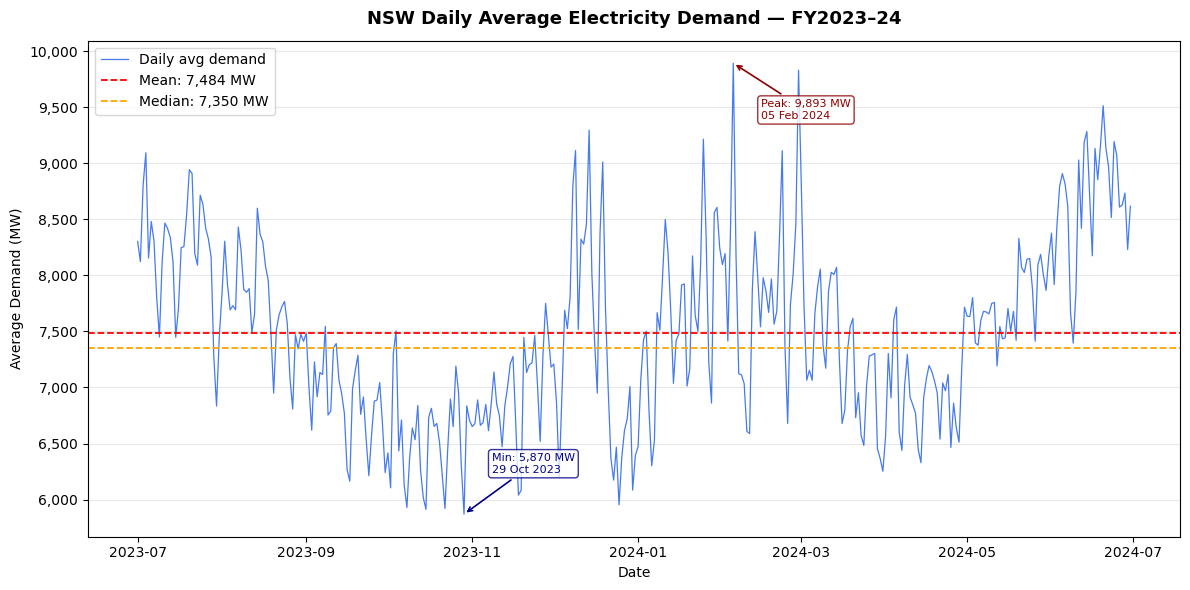

In [7]:
# Figure 1 - NSW Daily Average Electricity Demand
daily = df.groupby('date')['TOTALDEMAND'].mean().reset_index()
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily['date'], daily['TOTALDEMAND'],
        color='#2563eb', linewidth=0.9, alpha=0.85, label='Daily avg demand')
ax.axhline(mean_mw, color='red', linestyle='--', linewidth=1.3,
           label=f'Mean: {mean_mw:,.0f} MW')
ax.axhline(median_mw, color='orange', linestyle='--', linewidth=1.3,
           label=f'Median: {median_mw:,.0f} MW')
ax.set_title(f'NSW Daily Average Electricity Demand — {FINANCIAL_YEAR}',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Average Demand (MW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

peak_daily = daily.loc[daily['TOTALDEMAND'].idxmax()]
min_daily  = daily.loc[daily['TOTALDEMAND'].idxmin()]

ax.annotate(f"Peak: {peak_daily['TOTALDEMAND']:,.0f} MW\n{peak_daily['date'].strftime('%d %b %Y')}",
            xy=(peak_daily['date'], peak_daily['TOTALDEMAND']),
            xytext=(20, -40), textcoords='offset points',
            fontsize=8, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred', alpha=0.8))

ax.annotate(f"Min: {min_daily['TOTALDEMAND']:,.0f} MW\n{min_daily['date'].strftime('%d %b %Y')}",
            xy=(min_daily['date'], min_daily['TOTALDEMAND']),
            xytext=(20, 30), textcoords='offset points',
            fontsize=8, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkblue', alpha=0.8))

plt.tight_layout()
plt.show()

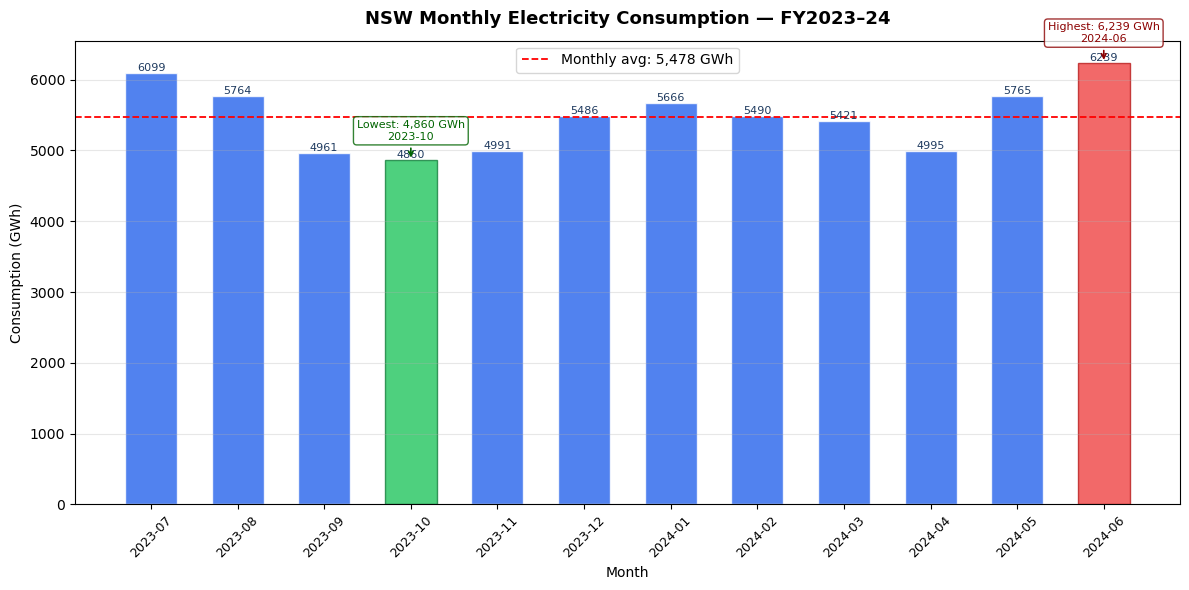

In [8]:
# Figure 2 - NSW Monthly Electricity Consumption
monthly_gwh  = df.groupby('yearmonth')['TOTALDEMAND'].sum() / 12 / 1000
month_labels = [str(m) for m in monthly_gwh.index]
 
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(monthly_gwh)), monthly_gwh.values,
              color='#2563eb', alpha=0.8, edgecolor='white', width=0.6)
ax.axhline(monthly_gwh.mean(), color='red', linestyle='--', linewidth=1.3,
           label=f'Monthly avg: {monthly_gwh.mean():,.0f} GWh')
for bar, val in zip(bars, monthly_gwh.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8, color='#1e3a5f')
ax.set_xticks(range(len(month_labels)))
ax.set_xticklabels(month_labels, rotation=45, fontsize=9)
ax.set_title(f'NSW Monthly Electricity Consumption — {FINANCIAL_YEAR}',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Consumption (GWh)')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Find highest and lowest months
max_idx = monthly_gwh.values.argmax()
min_idx = monthly_gwh.values.argmin()

# Highlight highest bar
bars[max_idx].set_color('#ef4444')  # red
bars[max_idx].set_edgecolor('#b91c1c')

# Highlight lowest bar
bars[min_idx].set_color('#22c55e')  # green
bars[min_idx].set_edgecolor('#15803d')

# Annotate highest
ax.annotate(f"Highest: {monthly_gwh.values[max_idx]:,.0f} GWh\n{month_labels[max_idx]}",
            xy=(max_idx, monthly_gwh.values[max_idx]),
            xytext=(0, 15), textcoords='offset points',
            fontsize=8, color='darkred', ha='center',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred', alpha=0.8))

# Annotate lowest
ax.annotate(f"Lowest: {monthly_gwh.values[min_idx]:,.0f} GWh\n{month_labels[min_idx]}",
            xy=(min_idx, monthly_gwh.values[min_idx]),
            xytext=(0, 15), textcoords='offset points',
            fontsize=8, color='darkgreen', ha='center',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkgreen', alpha=0.8))

plt.tight_layout()
plt.show()

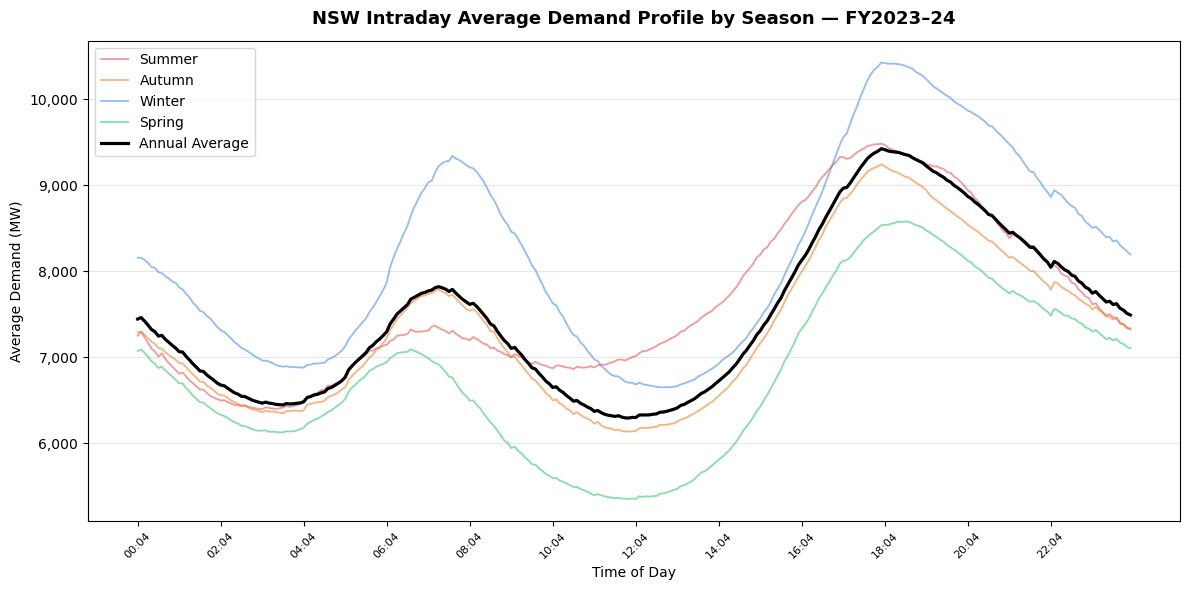

In [9]:
# Figure 3 - NSW Intraday Average Demand Profile by Season
intraday_all  = df.groupby('time')['TOTALDEMAND'].mean()
season_colors = {'Summer':'#ef4444','Autumn':'#f97316','Winter':'#3b82f6','Spring':'#22c55e'}
 
fig, ax = plt.subplots(figsize=(12, 6))
for season, color in season_colors.items():
    s = df[df['season'] == season].groupby('time')['TOTALDEMAND'].mean()
    ax.plot(range(len(s)), s.values,
            color=color, linewidth=1.3, alpha=0.55, label=season)
ax.plot(range(len(intraday_all)), intraday_all.values,
        color='black', linewidth=2.3, label='Annual Average')
 
ticks = list(range(0, len(intraday_all), 24))
ax.set_xticks(ticks)
ax.set_xticklabels([intraday_all.index[i] for i in ticks], rotation=45, fontsize=8)
ax.set_title(f'NSW Intraday Average Demand Profile by Season — {FINANCIAL_YEAR}',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Time of Day'); ax.set_ylabel('Average Demand (MW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'chart_b_intraday.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Demand Scenarios: Low, Medium, and High Growth

In [10]:
# NSW-scaled scenario calculations
national = {'Low': 8.5, 'Medium': 12.0, 'High': 17.0}  # TWh nationally
nsw_share = 0.60  # 60% — M3 Property (2025)
nsw_total = 65.7  # TWh — FY2023-24 baseline

for name, twh in national.items():
    nsw_twh = twh * nsw_share
    pct = nsw_twh / nsw_total * 100
    print(f"{name}: National={twh} TWh | NSW={nsw_twh:.1f} TWh | % of NSW={pct:.1f}%")

Low: National=8.5 TWh | NSW=5.1 TWh | % of NSW=7.8%
Medium: National=12.0 TWh | NSW=7.2 TWh | % of NSW=11.0%
High: National=17.0 TWh | NSW=10.2 TWh | % of NSW=15.5%


In [11]:
# ── IMPLIED FACILITY LOAD CALCULATION ─────────────────────────────────────────

hours = 8760

scenarios = {
    'Low Growth':    {'nat_twh': 8.5,  'nsw_share': 0.60, 'pue': 1.50, 'util': 0.55},
    'Medium Growth': {'nat_twh': 12.0, 'nsw_share': 0.60, 'pue': 1.40, 'util': 0.65},
    'High Growth':   {'nat_twh': 17.0, 'nsw_share': 0.60, 'pue': 1.30, 'util': 0.75},
}

print("=== IMPLIED FACILITY LOAD CALCULATION ===")
print(f"\n{'Scenario':<20} {'Nat TWh':>10} {'NSW TWh':>10} {'Facility MW':>14} {'IT Capacity':>14}")
print("-" * 75)

for name, s in scenarios.items():
    nsw_twh     = round(s['nat_twh'] * s['nsw_share'], 1)
    facility_mw = round(nsw_twh * 1_000_000 / hours, 0)
    it_mw       = round(facility_mw / s['pue'] / s['util'], 0)
    
    print(f"{name:<20} {s['nat_twh']:>10.1f} {nsw_twh:>10.1f} {facility_mw:>14,.0f} {it_mw:>14,.0f}")

print(f"\nFormula:")
print(f"  NSW TWh     = National TWh × 60% NSW share")
print(f"  Facility MW = NSW TWh × 1,000,000 ÷ {hours} hours")
print(f"  IT Capacity = Facility MW ÷ PUE ÷ Utilisation")

=== IMPLIED FACILITY LOAD CALCULATION ===

Scenario                Nat TWh    NSW TWh    Facility MW    IT Capacity
---------------------------------------------------------------------------
Low Growth                  8.5        5.1            582            705
Medium Growth              12.0        7.2            822            903
High Growth                17.0       10.2          1,164          1,194

Formula:
  NSW TWh     = National TWh × 60% NSW share
  Facility MW = NSW TWh × 1,000,000 ÷ 8760 hours
  IT Capacity = Facility MW ÷ PUE ÷ Utilisation


In [12]:
# SCENARIO INPUTS
import numpy as np
existing_nsw_dc = 2.4
nsw_baseline    = 65.7
years = list(range(2025, 2035))

def ramp_up(final_value, n_years=10):
    x = np.linspace(0, 1, n_years)
    return np.round(final_value * np.sqrt(x), 2)

scenario_inputs = {
    'Low Growth':    {'final_twh': 5.1,  'final_mw': 582,  'color': '#22c55e'},
    'Medium Growth': {'final_twh': 7.2,  'final_mw': 822,  'color': '#f97316'},
    'High Growth':   {'final_twh': 10.2, 'final_mw': 1164, 'color': '#ef4444'},
}

for name, s in scenario_inputs.items():
    s['twh_series'] = [existing_nsw_dc + t for t in ramp_up(s['final_twh'])]
    s['mw_series']  = ramp_up(s['final_mw'])
    s['pct_series'] = [t / nsw_baseline * 100 for t in s['twh_series']]
    s['total_twh']  = round(existing_nsw_dc + s['final_twh'], 1)
    s['total_pct']  = round(s['total_twh'] / nsw_baseline * 100, 1)

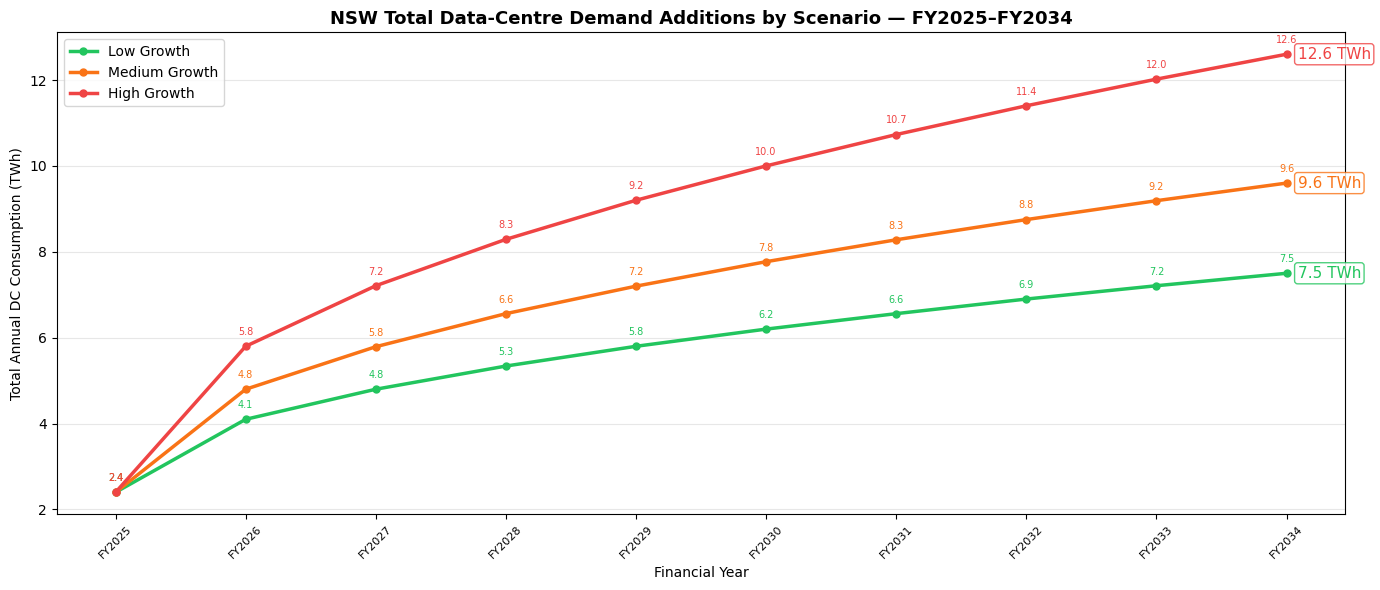

In [13]:
# Figure 4 — NSW New Data-Centre Demand Additions by Scenario, FY2025–FY2034
fig, ax = plt.subplots(figsize=(14, 6))
for name, s in scenario_inputs.items():
    ax.plot(years, s['twh_series'], color=s['color'], linewidth=2.5,
            marker='o', markersize=5, label=name)
    for yr, val in zip(years, s['twh_series']):
        ax.annotate(f"{val:.1f}",
                    xy=(yr, val), xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=7, ha='center', color=s['color'])
    ax.annotate(f"{s['total_twh']} TWh",
                xy=(2034, s['twh_series'][-1]),
                xytext=(8, 0), textcoords='offset points',
                color=s['color'], fontsize=11, va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=s['color'], alpha=0.8))
ax.set_title('NSW Total Data-Centre Demand Additions by Scenario — FY2025–FY2034',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Total Annual DC Consumption (TWh)')
ax.set_xticks(years)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

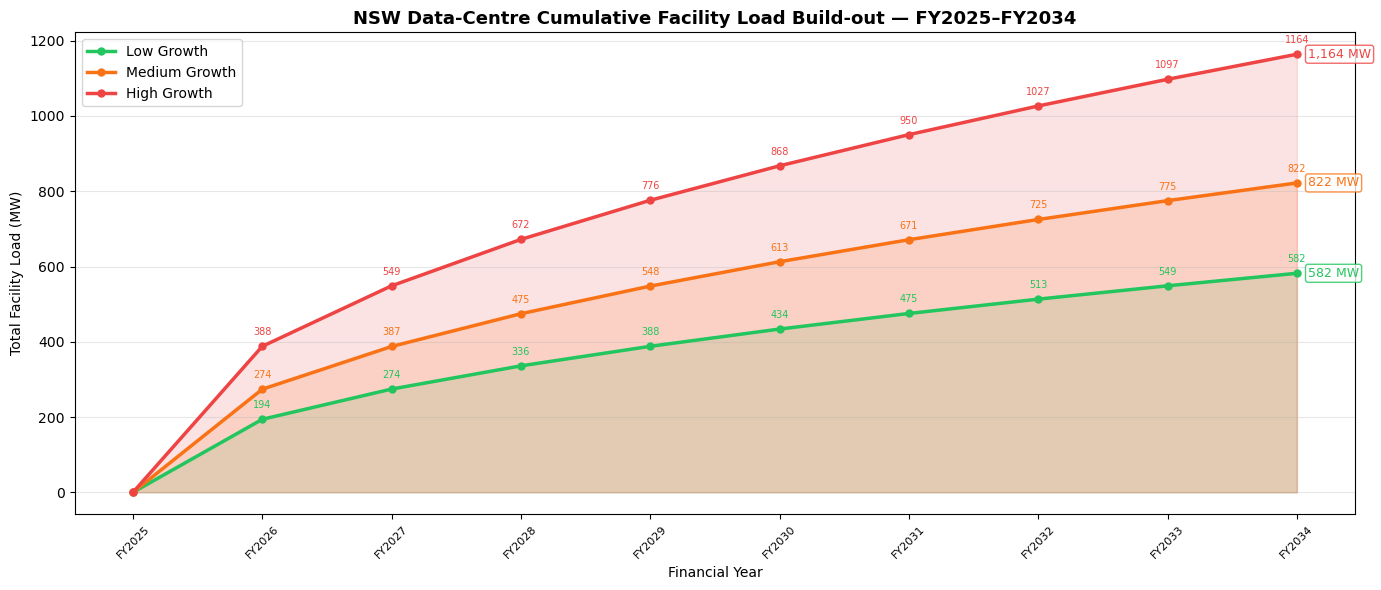

In [14]:
# Figure 5 — NSW New Data-Centre Demand as % of NSW Baseline, FY2025–FY2034
fig, ax = plt.subplots(figsize=(14, 6))
for name, s in scenario_inputs.items():
    ax.fill_between(years, s['mw_series'], alpha=0.15, color=s['color'])
    ax.plot(years, s['mw_series'], color=s['color'], linewidth=2.5,
            marker='o', markersize=5, label=name)
    for yr, val in zip(years, s['mw_series']):
        if yr == 2025:
            continue
        ax.annotate(f"{val:.0f}",
                    xy=(yr, val), xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=7, ha='center', color=s['color'])
    ax.annotate(f"{s['final_mw']:,} MW",
                xy=(2034, s['mw_series'][-1]),
                xytext=(8, 0), textcoords='offset points',
                color=s['color'], fontsize=9, va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=s['color'], alpha=0.8))
ax.set_title('NSW Data-Centre Cumulative Facility Load Build-out — FY2025–FY2034',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Total Facility Load (MW)')
ax.set_xticks(years)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

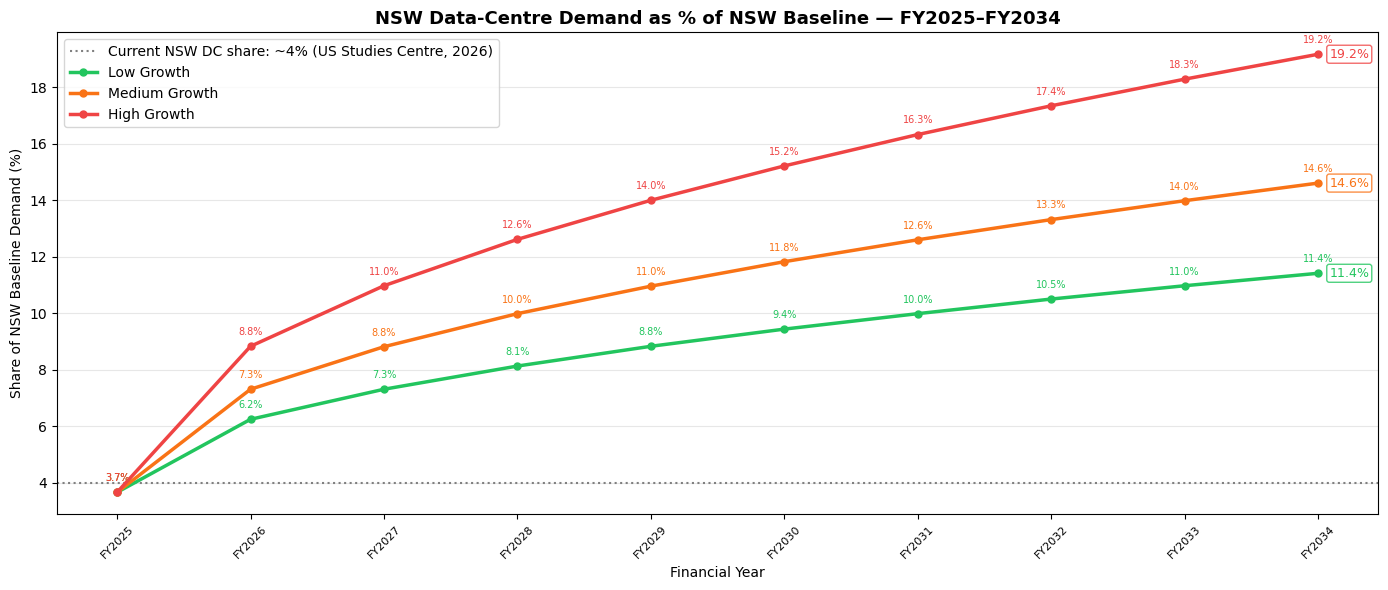

In [15]:
# Figure 6 — NSW Data-Centre Cumulative Facility Load Build-out, FY2025–FY2034
fig, ax = plt.subplots(figsize=(14, 6))
ax.axhline(4.0, color='grey', linestyle=':', linewidth=1.5,
           label='Current NSW DC share: ~4% (US Studies Centre, 2026)')
for name, s in scenario_inputs.items():
    ax.plot(years, s['pct_series'], color=s['color'], linewidth=2.5,
            marker='o', markersize=5, label=name)
    for yr, val in zip(years, s['pct_series']):
        ax.annotate(f"{val:.1f}%",
                    xy=(yr, val), xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=7, ha='center', color=s['color'])
    ax.annotate(f"{s['total_pct']:.1f}%",
                xy=(2034, s['pct_series'][-1]),
                xytext=(8, 0), textcoords='offset points',
                color=s['color'], fontsize=9, va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=s['color'], alpha=0.8))
ax.set_title('NSW Data-Centre Demand as % of NSW Baseline — FY2025–FY2034',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Financial Year')
ax.set_ylabel('Share of NSW Baseline Demand (%)')
ax.set_xticks(years)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4 Significance Relative to NSW Total Demand

In [16]:
# ── TABLE 4.1 & 4.2 CALCULATIONS ─────────────────────────────────────────────
existing_nsw_dc = 2.4
nsw_baseline    = 65.7
nem_growth      = 0.0255
years           = list(range(2025, 2035))

def ramp_up(final_value, n_years=10):
    x = np.linspace(0, 1, n_years)
    return np.round(final_value * np.sqrt(x), 2)

scenarios = {
    'Low Growth':    5.1,
    'Medium Growth': 7.2,
    'High Growth':   10.2,
}

# Calculate total DC series for each scenario
total_dc = {}
for name, new_twh in scenarios.items():
    series = ramp_up(new_twh)
    total_dc[name] = [round(existing_nsw_dc + t, 1) for t in series]

# Growing baseline series
nsw_growing = [round(nsw_baseline * (1 + nem_growth) ** (yr - 2025), 1)
               for yr in years]

# ── TABLE 4.1 — Static baseline ───────────────────────────────────────────────
print("=== TABLE 4.1 — STATIC BASELINE (65.7 TWh) ===")
print(f"{'Year':<8} {'NSW Baseline':>14} {'Low Growth':>20} {'Medium Growth':>20} {'High Growth':>20}")
print("-" * 85)

for i, yr in enumerate(years):
    row = [f"FY{yr}", f"{nsw_baseline} TWh"]
    for name in scenarios:
        val = total_dc[name][i]
        pct = round(val / nsw_baseline * 100, 1)
        row.append(f"{val} TWh ({pct}%)")
    print(f"{row[0]:<8} {row[1]:>14} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

# ── TABLE 4.2 — Growing baseline ──────────────────────────────────────────────
print("\n=== TABLE 4.2 — GROWING BASELINE (NEM CAGR 2.55% p.a.) ===")
print(f"{'Year':<8} {'NSW Baseline':>14} {'Low Growth':>20} {'Medium Growth':>20} {'High Growth':>20}")
print("-" * 85)

for i, yr in enumerate(years):
    baseline = nsw_growing[i]
    row = [f"FY{yr}", f"{baseline} TWh"]
    for name in scenarios:
        val = total_dc[name][i]
        pct = round(val / baseline * 100, 1)
        row.append(f"{val} TWh ({pct}%)")
    print(f"{row[0]:<8} {row[1]:>14} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

# ── KEY DIFFERENCES ───────────────────────────────────────────────────────────
print("\n=== KEY DIFFERENCES AT FY2034 ===")
print(f"{'Scenario':<20} {'Static %':>12} {'Growing %':>12} {'Difference':>12}")
print("-" * 60)
for name in scenarios:
    val = total_dc[name][-1]
    static_pct  = round(val / nsw_baseline * 100, 1)
    growing_pct = round(val / nsw_growing[-1] * 100, 1)
    diff = round(static_pct - growing_pct, 1)
    print(f"{name:<20} {static_pct:>11}% {growing_pct:>11}% {diff:>11}%")

=== TABLE 4.1 — STATIC BASELINE (65.7 TWh) ===
Year       NSW Baseline           Low Growth        Medium Growth          High Growth
-------------------------------------------------------------------------------------
FY2025         65.7 TWh       2.4 TWh (3.7%)       2.4 TWh (3.7%)       2.4 TWh (3.7%)
FY2026         65.7 TWh       4.1 TWh (6.2%)       4.8 TWh (7.3%)       5.8 TWh (8.8%)
FY2027         65.7 TWh       4.8 TWh (7.3%)       5.8 TWh (8.8%)      7.2 TWh (11.0%)
FY2028         65.7 TWh       5.3 TWh (8.1%)      6.6 TWh (10.0%)      8.3 TWh (12.6%)
FY2029         65.7 TWh       5.8 TWh (8.8%)      7.2 TWh (11.0%)      9.2 TWh (14.0%)
FY2030         65.7 TWh       6.2 TWh (9.4%)      7.8 TWh (11.9%)     10.0 TWh (15.2%)
FY2031         65.7 TWh      6.6 TWh (10.0%)      8.3 TWh (12.6%)     10.7 TWh (16.3%)
FY2032         65.7 TWh      6.9 TWh (10.5%)      8.8 TWh (13.4%)     11.4 TWh (17.4%)
FY2033         65.7 TWh      7.2 TWh (11.0%)      9.2 TWh (14.0%)     12.0 TWh (18.3

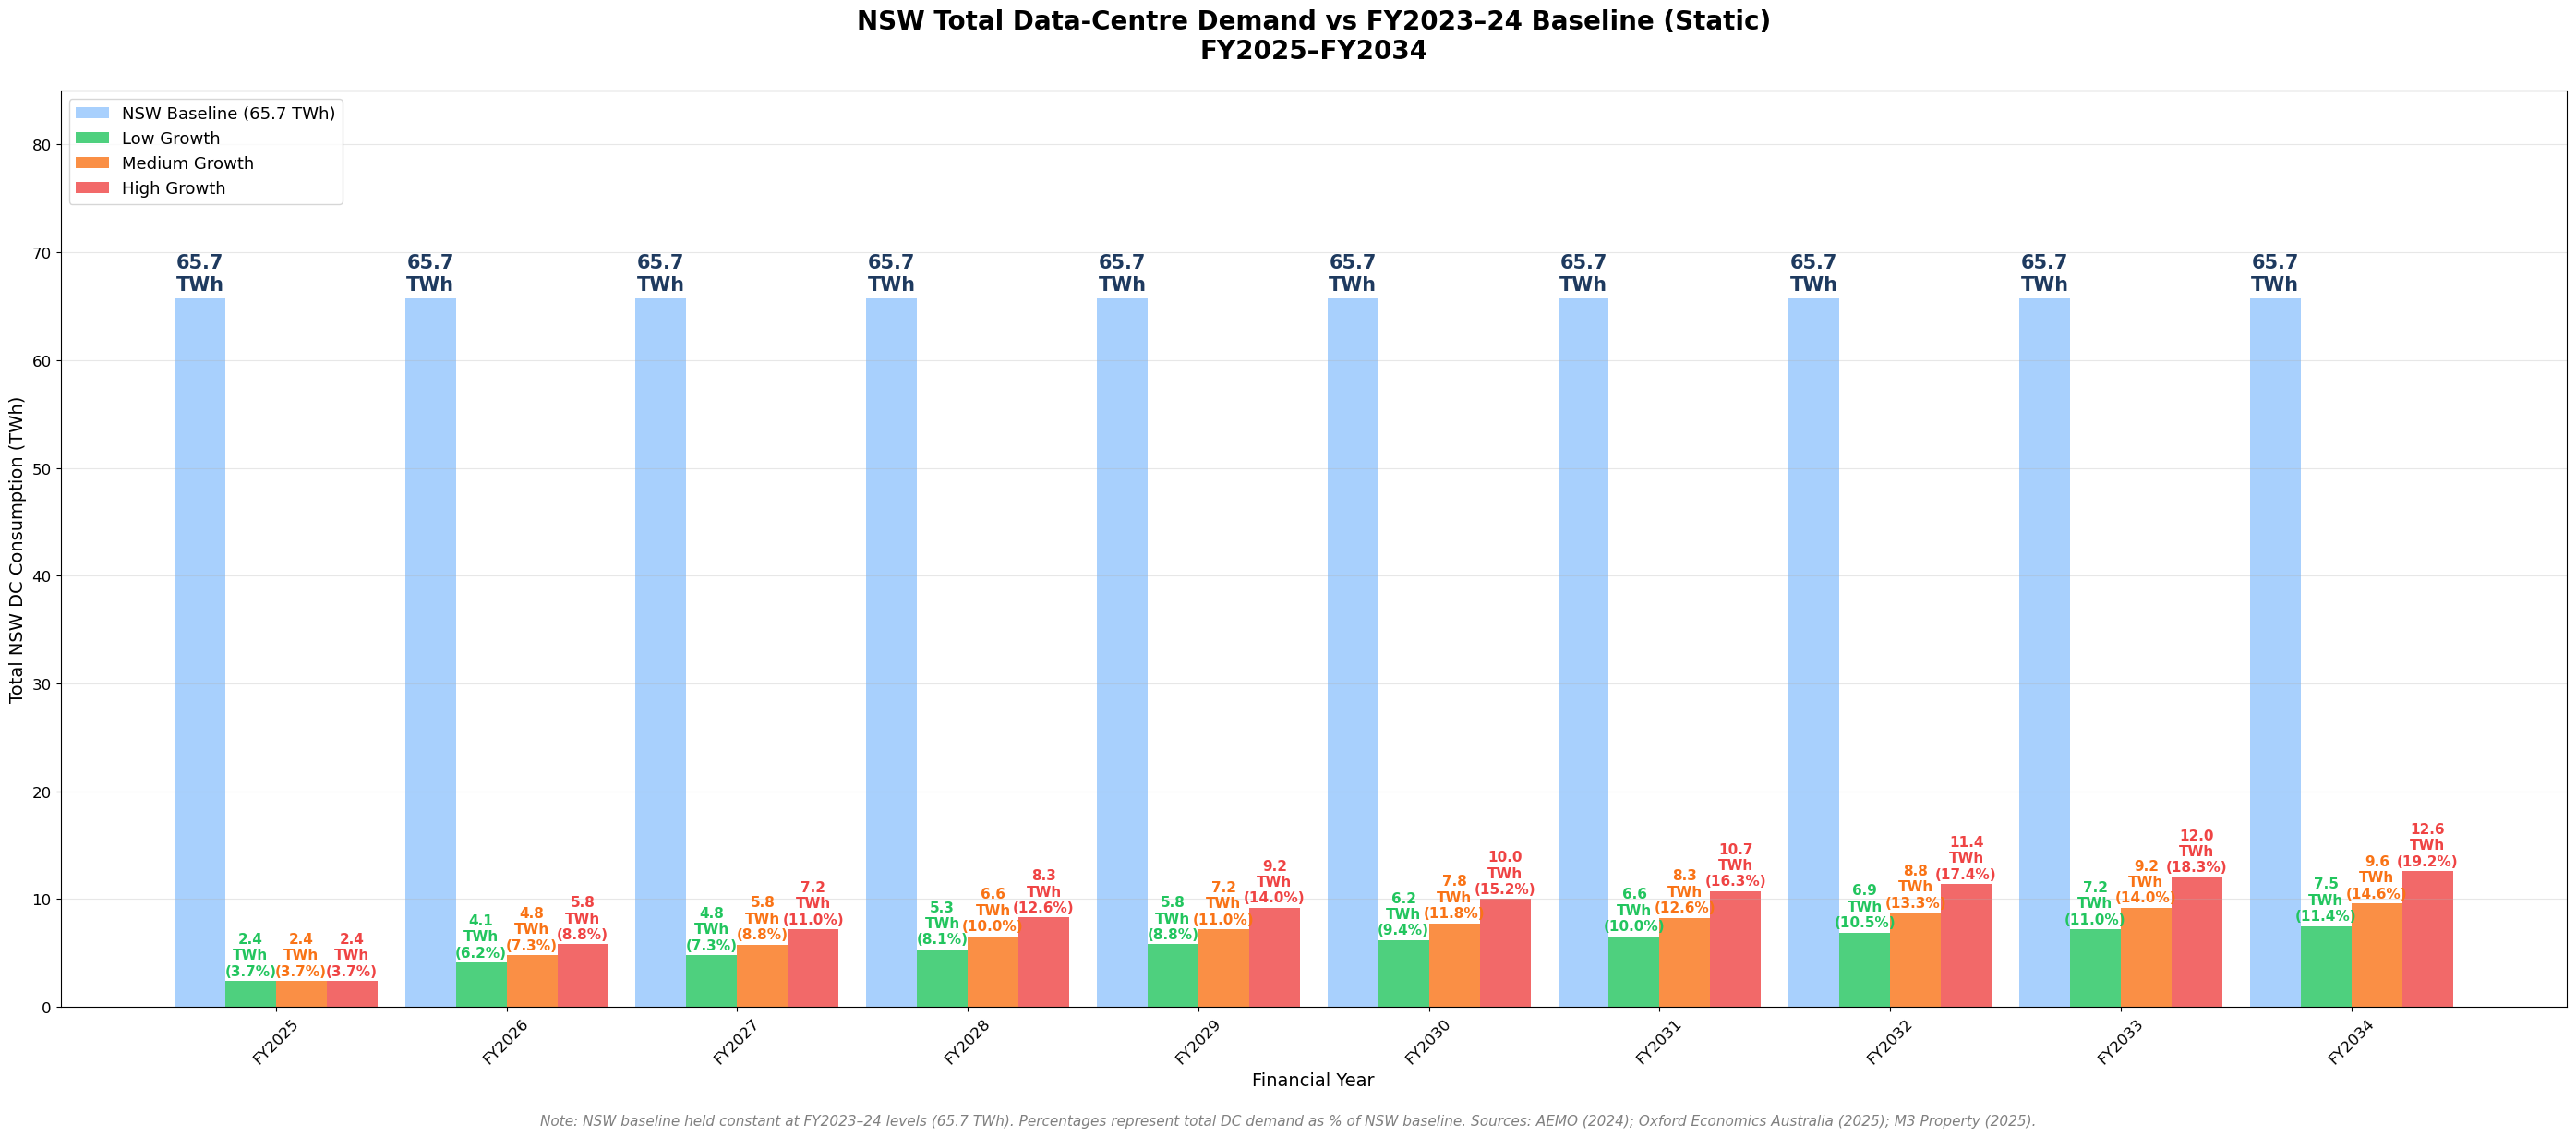

In [17]:
# FIGURE 7.1 — Static baseline
nsw_baseline_static = 65.7
existing_dc = 2.4
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.22

fig, ax = plt.subplots(figsize=(28, 12))

# NSW baseline bars
baseline_bars = ax.bar(x - 1.5*width, [nsw_baseline_static]*len(years),
                       width, color='#93c5fd', alpha=0.8,
                       label=f'NSW Baseline ({nsw_baseline_static} TWh)')
for bar in baseline_bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{nsw_baseline_static}\nTWh',
            ha='center', va='bottom', fontsize=15, color='#1e3a5f',
            fontweight='bold')

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 0.5) * width
    bars = ax.bar(x + offset, s['twh_series'],
                  width, color=s['color'], alpha=0.8, label=name)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}\nTWh\n({pct:.1f}%)',
                ha='center', va='bottom',
                fontsize=11, color=s['color'], fontweight='bold')

ax.set_title('NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
             fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Financial Year', fontsize=14)
ax.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=12)
ax.legend(fontsize=13, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 85)
ax.tick_params(axis='y', labelsize=12)

fig.text(0.5, -0.02,
         'Note: NSW baseline held constant at FY2023–24 levels (65.7 TWh). '
         'Percentages represent total DC demand as % of NSW baseline. '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=11, style='italic', color='grey')

plt.tight_layout()
plt.show()

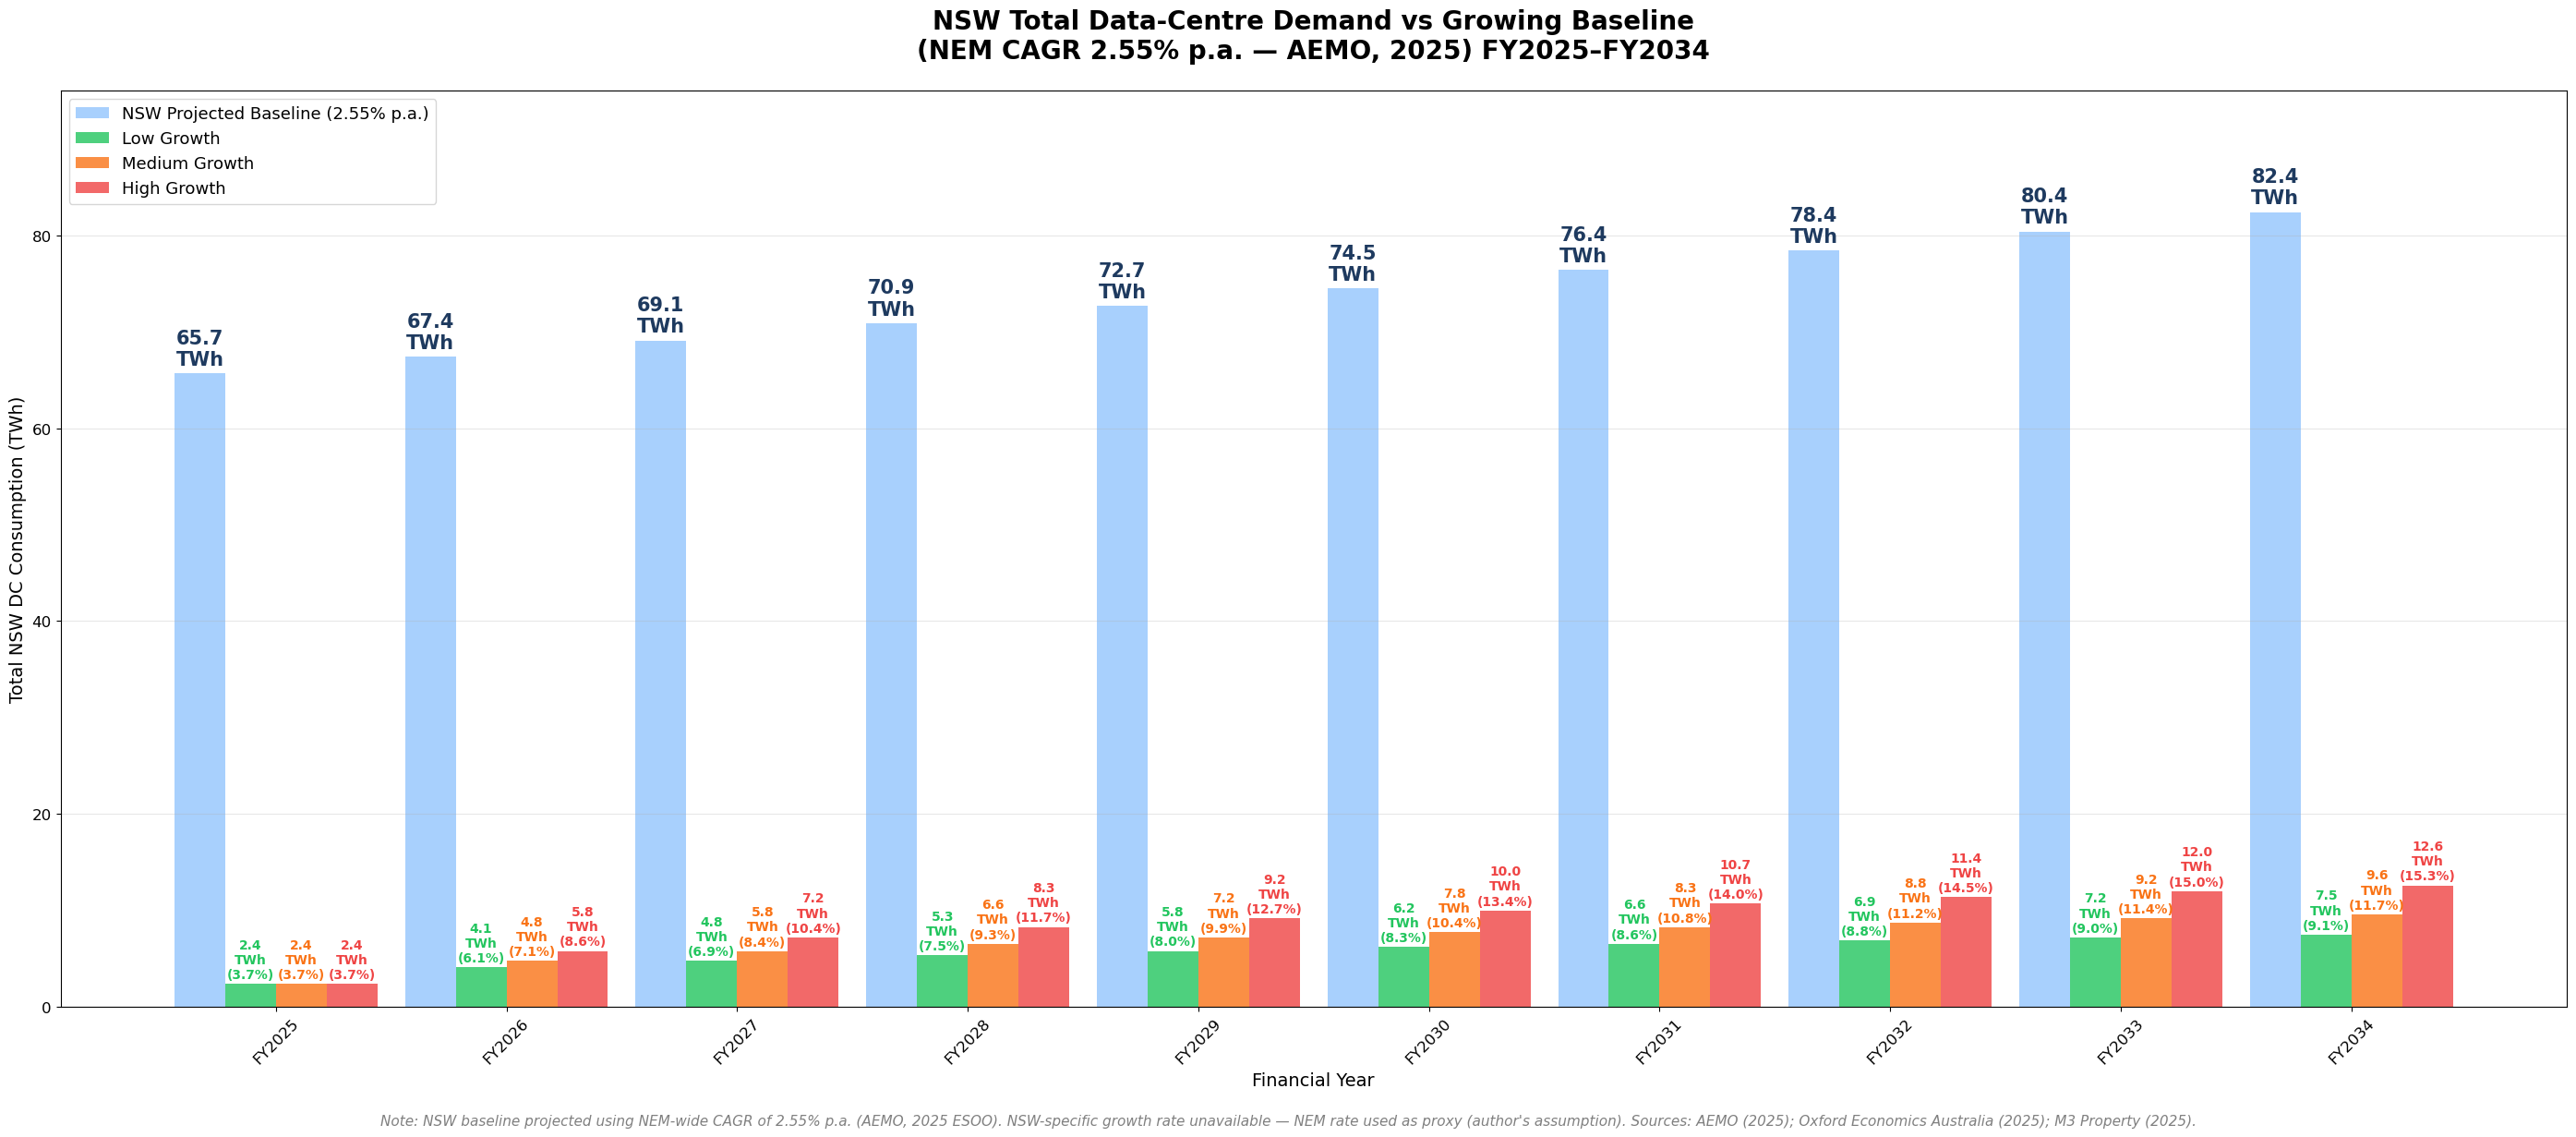

In [18]:
# FIGURE 7.2 — Growing baseline
nem_growth = 0.0255
nsw_growing_series = [round(65.7 * (1 + nem_growth) ** (yr - 2025), 1)
                      for yr in years]

fig, ax = plt.subplots(figsize=(28, 12))

# NSW growing baseline bars
baseline_bars = ax.bar(x - 1.5*width, nsw_growing_series,
                       width, color='#93c5fd', alpha=0.8,
                       label='NSW Projected Baseline (2.55% p.a.)')
for i, (bar, val) in enumerate(zip(baseline_bars, nsw_growing_series)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}\nTWh',
            ha='center', va='bottom', fontsize=15, color='#1e3a5f',
            fontweight='bold')

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 0.5) * width
    bars = ax.bar(x + offset, s['twh_series'],
                  width, color=s['color'], alpha=0.8, label=name)
    for i, (bar, val) in enumerate(zip(bars, s['twh_series'])):
        baseline = nsw_growing_series[i]
        pct = val / baseline * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}\nTWh\n({pct:.1f}%)',
                ha='center', va='bottom',
                fontsize=10, color=s['color'], fontweight='bold')

ax.set_title('NSW Total Data-Centre Demand vs Growing Baseline\n(NEM CAGR 2.55% p.a. — AEMO, 2025) FY2025–FY2034',
             fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Financial Year', fontsize=14)
ax.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=12)
ax.legend(fontsize=13, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 95)
ax.tick_params(axis='y', labelsize=12)

fig.text(0.5, -0.02,
         'Note: NSW baseline projected using NEM-wide CAGR of 2.55% p.a. (AEMO, 2025 ESOO). '
         'NSW-specific growth rate unavailable — NEM rate used as proxy (author\'s assumption). '
         'Sources: AEMO (2025); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=11, style='italic', color='grey')

plt.tight_layout()
plt.show()

## 2.5 Sensitivity Analysis and Key Uncertainties

In [19]:
base_nat_twh = 12.0
base_share   = 0.60
base_twh     = 7.2
base_pue     = 1.40
base_util    = 0.65

sensitivities = {
    'NSW Share\n(±10%)':        (round(base_nat_twh * 0.50, 1),
                                  round(base_nat_twh * 0.70, 1)),
    'Utilisation Rate\n(±10%)': (round(base_twh * (0.55/base_util), 1),
                                  round(base_twh * (0.75/base_util), 1)),
    'PUE\n(±0.10)':             (round(base_twh * (1.30/base_pue), 1),
                                  round(base_twh * (1.50/base_pue), 1)),
}

print(f"Base case: {base_twh} TWh")
print(f"\n=== SENSITIVITY RESULTS ===")
print(f"{'Assumption':<30} {'Low':>8} {'Base':>8} {'High':>8} {'Range':>8}")
print("-" * 60)
for name, (low, high) in sensitivities.items():
    clean = name.replace('\n', ' ')
    print(f"{clean:<30} {low:>8.1f} {base_twh:>8.1f} {high:>8.1f} {high-low:>8.1f}")

Base case: 7.2 TWh

=== SENSITIVITY RESULTS ===
Assumption                          Low     Base     High    Range
------------------------------------------------------------
NSW Share (±10%)                    6.0      7.2      8.4      2.4
Utilisation Rate (±10%)             6.1      7.2      8.3      2.2
PUE (±0.10)                         6.7      7.2      7.7      1.0


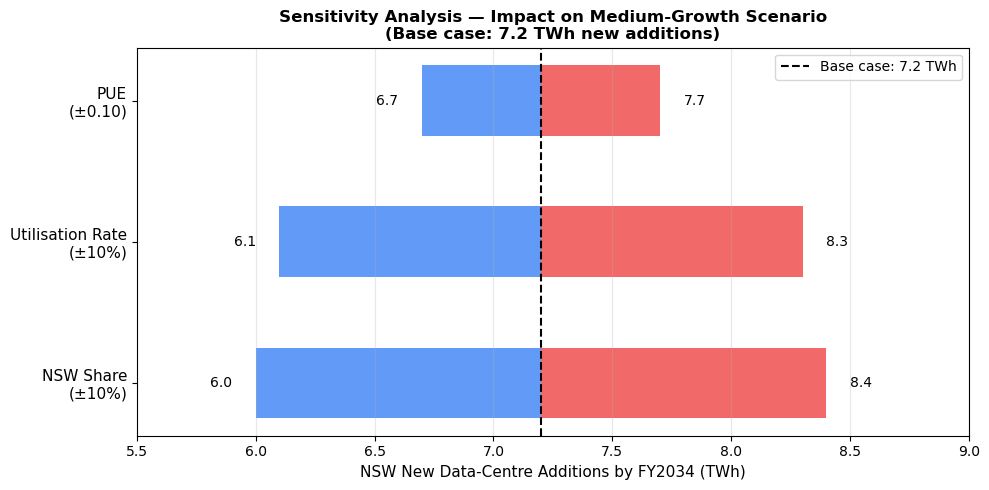

In [20]:
# Figure 8 - Sensitivity Analysis Tornado Chart
fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, (low, high)) in enumerate(sensitivities.items()):
    ax.barh(i, base_twh - low, left=low,
            color='#3b82f6', alpha=0.8, height=0.5)
    ax.barh(i, high - base_twh, left=base_twh,
            color='#ef4444', alpha=0.8, height=0.5)
    ax.text(low - 0.1, i, f'{low}', ha='right', va='center', fontsize=10)
    ax.text(high + 0.1, i, f'{high}', ha='left', va='center', fontsize=10)

ax.axvline(base_twh, color='black', linestyle='--', linewidth=1.5,
           label=f'Base case: {base_twh} TWh')
ax.set_yticks(range(len(sensitivities)))
ax.set_yticklabels(sensitivities.keys(), fontsize=11)
ax.set_xlabel('NSW New Data-Centre Additions by FY2034 (TWh)', fontsize=11)
ax.set_title('Sensitivity Analysis — Impact on Medium-Growth Scenario\n(Base case: 7.2 TWh new additions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(5.5, 9.0)
plt.tight_layout()
plt.show()

## 2.4 New Version

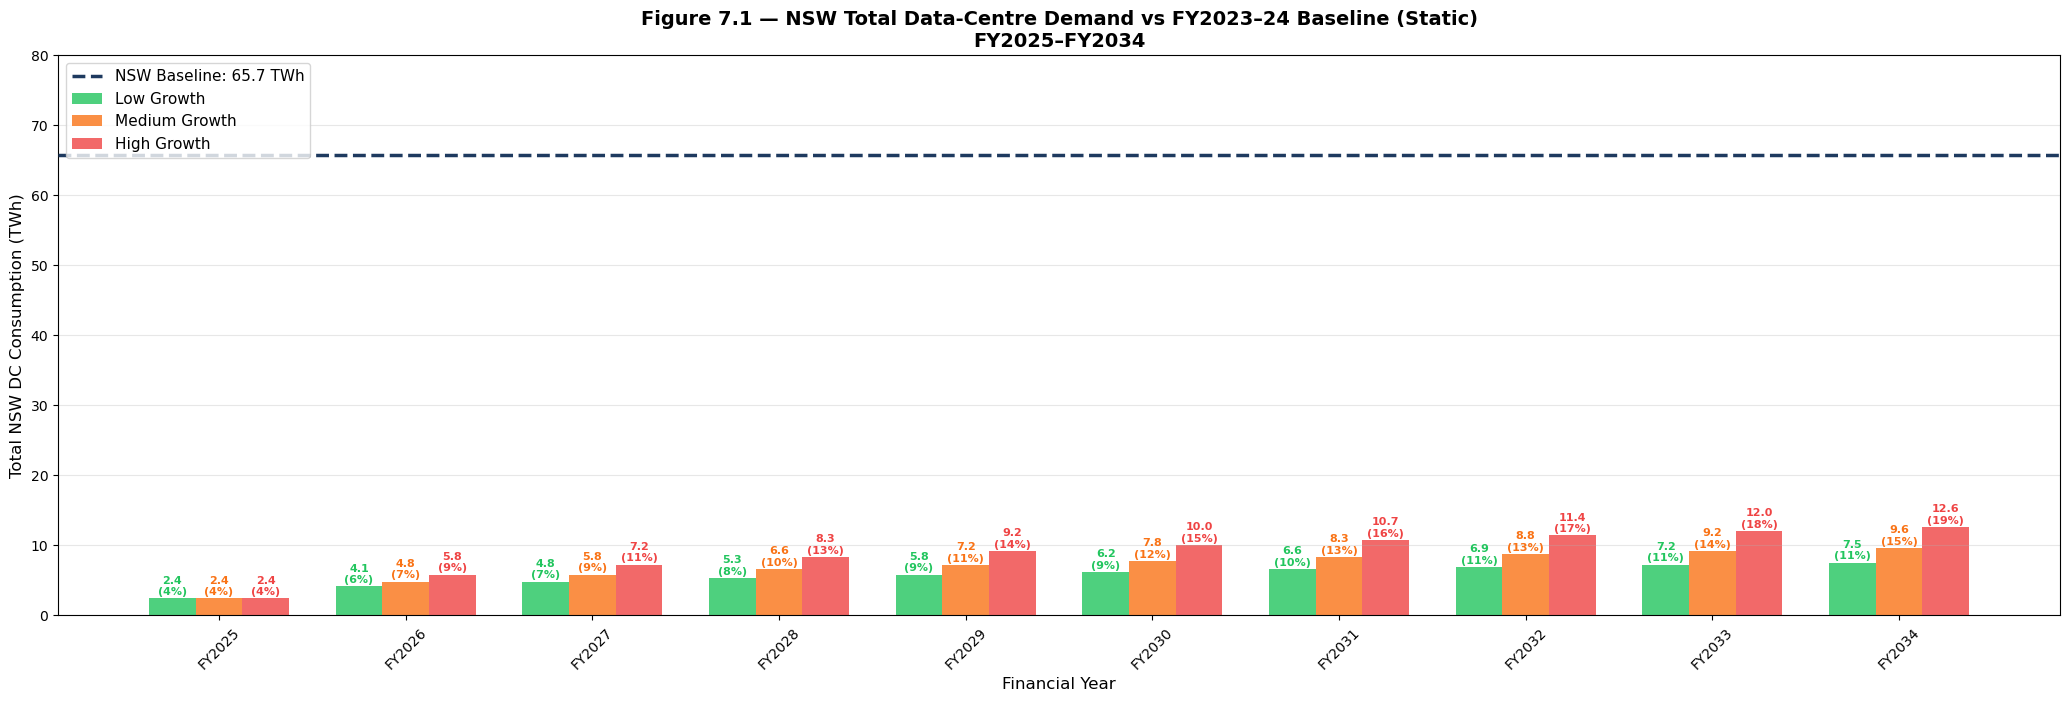

In [21]:
# ── FIGURE 7.1 — Baseline as line, scenarios as bars, static ─────────────────
nsw_baseline_static = 65.7
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(22, 8))

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 1) * width
    bars = ax.bar(x + offset, s['twh_series'],
                  width, color=s['color'], alpha=0.8, label=name)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}\n({pct:.0f}%)',
                ha='center', va='bottom',
                fontsize=8, color=s['color'], fontweight='bold')

# NSW baseline as line
ax.axhline(nsw_baseline_static, color='#1e3a5f', linestyle='--',
           linewidth=2.5, label=f'NSW Baseline: {nsw_baseline_static} TWh',
           zorder=5)

ax.set_title('Figure 7.1 — NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Financial Year', fontsize=12)
ax.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=10)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 80)

plt.subplots_adjust(left=0.06, right=0.97, bottom=0.18, top=0.88)
plt.show()

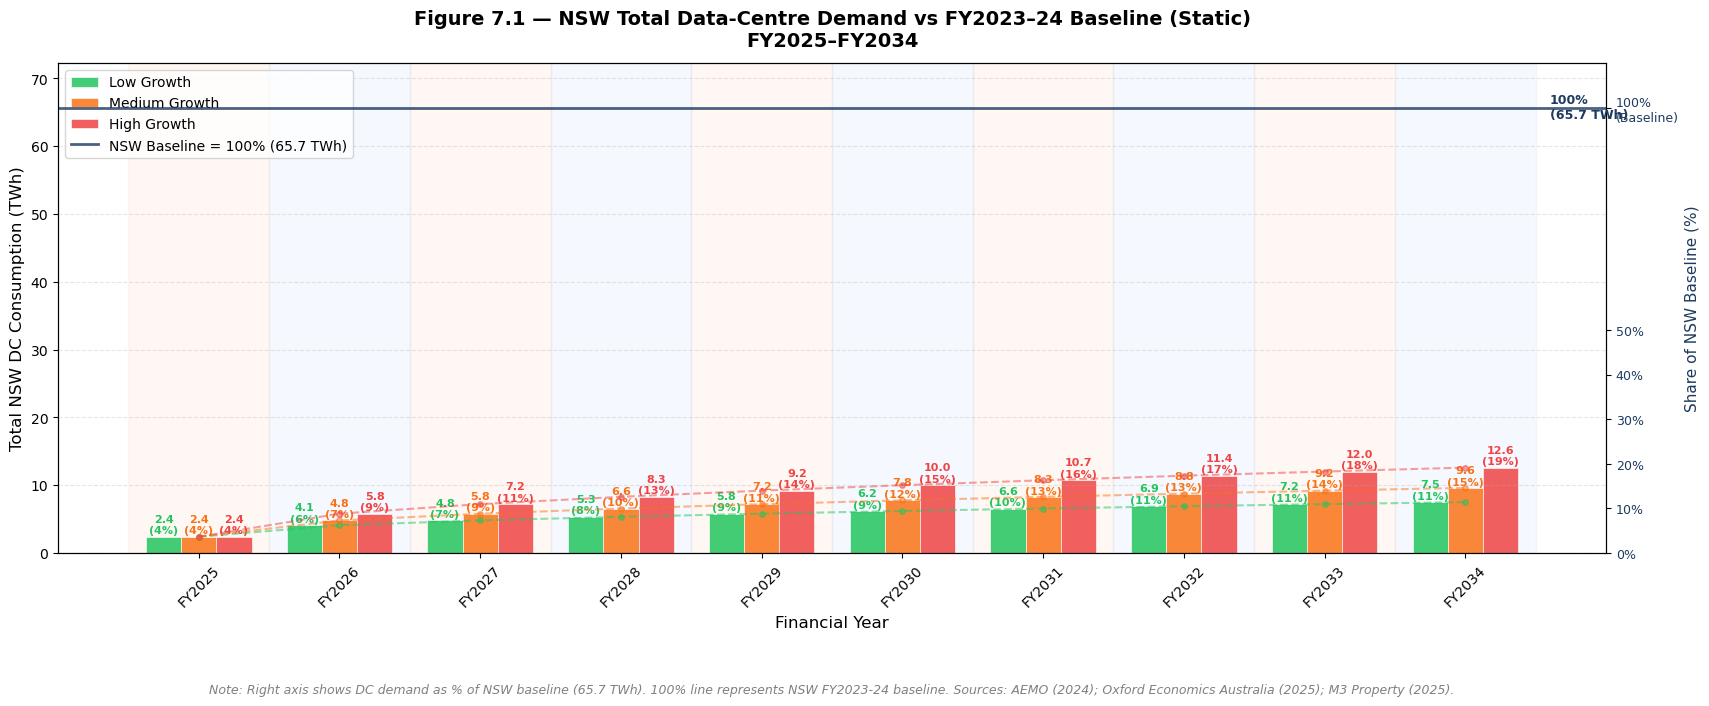

In [22]:
# ── FIGURE 7.1 — Right axis scaled to show baseline ──────────────────────────
nsw_baseline_static = 65.7
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.25

fig, ax1 = plt.subplots(figsize=(18, 7))

# Alternating year shading
for i in range(0, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#f97316')
for i in range(1, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#3b82f6')

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 1) * width
    bars = ax1.bar(x + offset, s['twh_series'],
                   width, color=s['color'], alpha=0.85,
                   label=name, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f'{val:.1f}\n({pct:.0f}%)',
                 ha='center', va='bottom',
                 fontsize=8, color=s['color'], fontweight='bold')

# Secondary axis — scale so 100% = 65.7 TWh
ax2 = ax1.twinx()

# Plot % lines
for idx, (name, s) in enumerate(scenario_inputs.items()):
    pct_series = [v / nsw_baseline_static * 100 for v in s['twh_series']]
    ax2.plot(x, pct_series, color=s['color'],
             linewidth=1.5, linestyle='--',
             marker='o', markersize=4, alpha=0.5)

# Add 100% reference line (= NSW baseline)
ax2.axhline(100, color='#1e3a5f', linestyle='-',
            linewidth=2, alpha=0.8,
            label=f'NSW Baseline = 100% ({nsw_baseline_static} TWh)')
ax2.text(9.6, 100, '100%\n(65.7 TWh)',
         fontsize=9, color='#1e3a5f', fontweight='bold', va='center')

ax1.set_title('Figure 7.1 — NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Financial Year', fontsize=12)
ax1.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)
ax2.set_ylabel('Share of NSW Baseline (%)', fontsize=11, color='#1e3a5f')
ax2.tick_params(axis='y', labelcolor='#1e3a5f')

# Set right axis ticks at 0, 10, 20, 30, 40, 50, 100
ax2.set_yticks([0, 10, 20, 30, 40, 50, 100])
ax2.set_yticklabels(['0%', '10%', '20%', '30%', '40%', '50%', '100%\n(Baseline)'],
                    fontsize=9, color='#1e3a5f')
ax2.set_ylim(0, 110)

# Scale left axis to match
ax1.set_ylim(0, nsw_baseline_static * 110/100)

ax1.set_xticks(x)
ax1.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=10)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.5, -0.02,
         f'Note: Right axis shows DC demand as % of NSW baseline ({nsw_baseline_static} TWh). '
         '100% line represents NSW FY2023-24 baseline. '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=9, style='italic', color='grey')

plt.subplots_adjust(left=0.07, right=0.93, bottom=0.18, top=0.88)
plt.show()

ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (5).

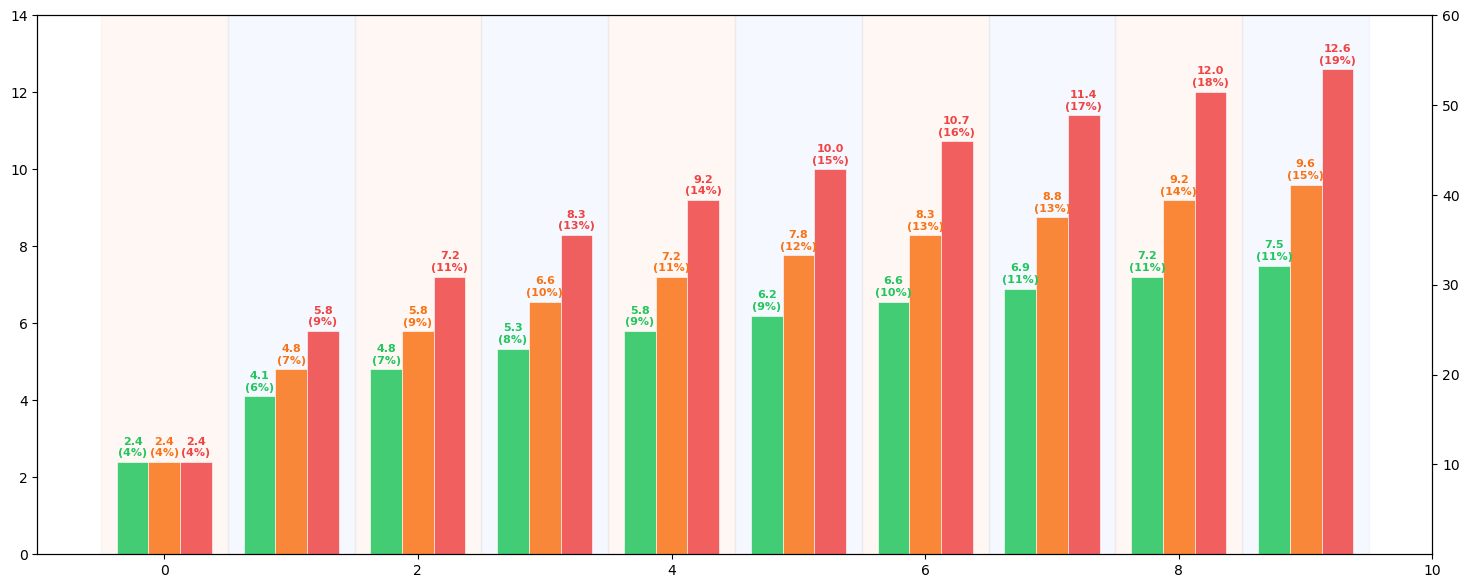

In [23]:
# ── FIGURE 7.1 — Clean axes, no extra lines ───────────────────────────────────
nsw_baseline_static = 65.7
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.25

fig, ax1 = plt.subplots(figsize=(18, 7))

# Alternating year shading
for i in range(0, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#f97316')
for i in range(1, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#3b82f6')

# Scenario bars only — no lines
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 1) * width
    bars = ax1.bar(x + offset, s['twh_series'],
                   width, color=s['color'], alpha=0.85,
                   label=name, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}\n({pct:.0f}%)',
                 ha='center', va='bottom',
                 fontsize=8, color=s['color'], fontweight='bold')

# Secondary axis — % only, no lines plotted
ax2 = ax1.twinx()

# Set axes
ax1.set_ylim(0, 14)
ax1.set_yticks([0, 2, 4, 6, 8, 10, 12, 14])
ax1.set_yticklabels(['0', '2', '4', '6', '8', '10', '12', '14'],
                    fontsize=10)

ax2.set_ylim(0, nsw_baseline_static * 14 / nsw_baseline_static * 100 / nsw_baseline_static)
# Simpler — just set % range matching left axis
ax2.set_ylim(0, 14 / nsw_baseline_static * 100)
ax2.set_yticks([10, 20, 30, 40, 50, 60])  # ← right axis ticks
ax2.set_yticklabels(['0%', '10%', '20%', '30%', '40%'],
                    fontsize=10, color='#1e3a5f')

ax1.set_title('Figure 7.1 — NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Financial Year', fontsize=12)
ax1.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)
ax2.set_ylabel('Share of NSW Baseline (%)', fontsize=11, color='#1e3a5f')
ax2.tick_params(axis='y', labelcolor='#1e3a5f')

ax1.set_xticks(x)
ax1.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=10)

# Add baseline note as text box
ax1.text(0.98, 0.97,
         f'NSW Baseline (FY2023-24): {nsw_baseline_static} TWh',
         transform=ax1.transAxes,
         fontsize=9, color='#1e3a5f', fontweight='bold',
         va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f0fe',
                   edgecolor='#1e3a5f', alpha=0.9))

ax1.legend(fontsize=10, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.5, -0.02,
         f'Note: NSW baseline of {nsw_baseline_static} TWh (FY2023-24) shown as reference. '
         'Right axis shows DC demand as % of NSW baseline. '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=9, style='italic', color='grey')

plt.subplots_adjust(left=0.07, right=0.93, bottom=0.18, top=0.88)
plt.show()

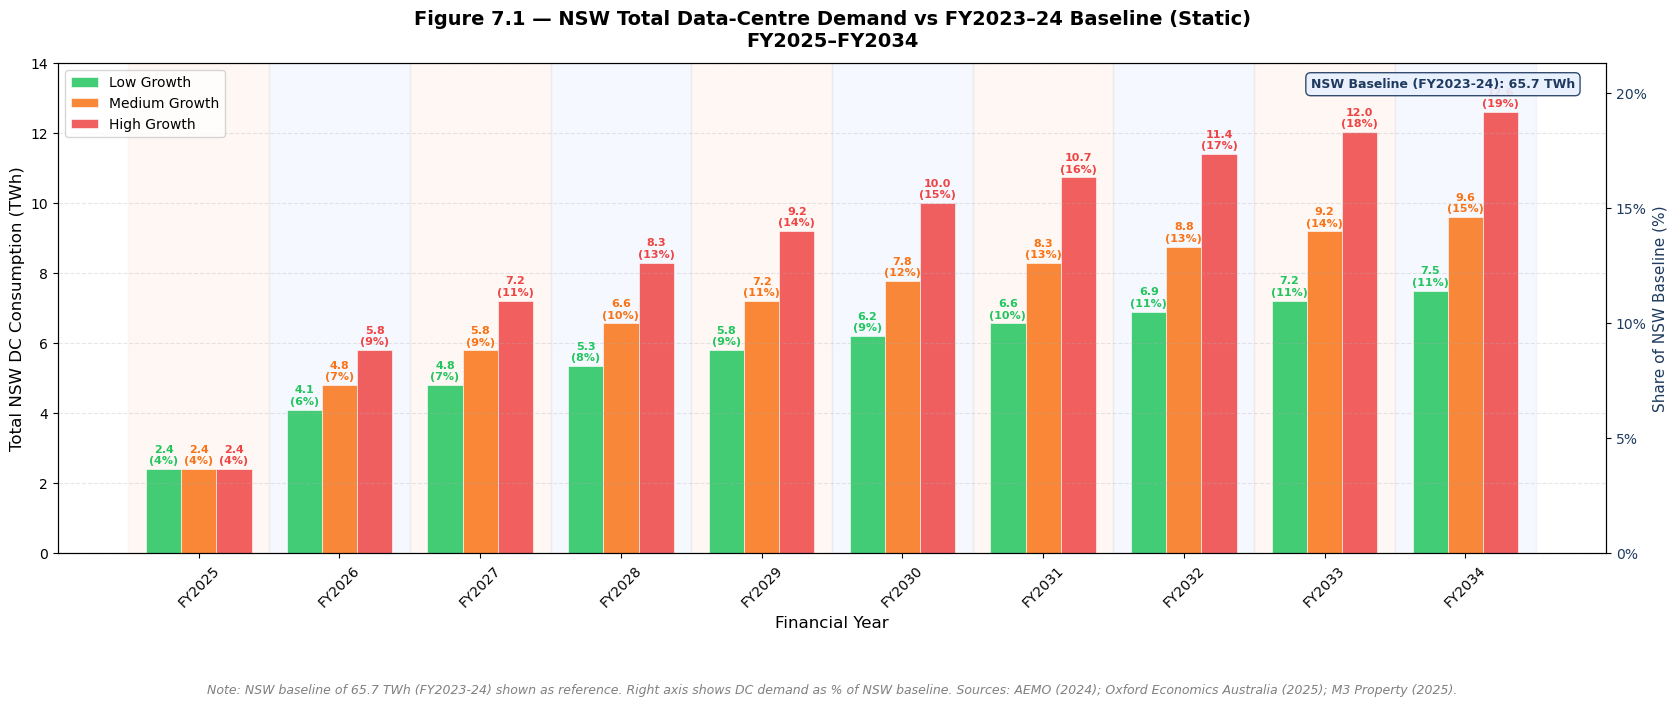

In [24]:
# ── FIGURE 7.1 — Static baseline ─────────────────────────────────────────────
nsw_baseline_static = 65.7
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.25

fig, ax1 = plt.subplots(figsize=(18, 7))

# Alternating year shading
for i in range(0, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#f97316')
for i in range(1, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#3b82f6')

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 1) * width
    bars = ax1.bar(x + offset, s['twh_series'],
                   width, color=s['color'], alpha=0.85,
                   label=name, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}\n({pct:.0f}%)',
                 ha='center', va='bottom',
                 fontsize=8, color=s['color'], fontweight='bold')

# Secondary axis
ax2 = ax1.twinx()

# Left axis
ax1.set_ylim(0, 14)
ax1.set_yticks([0, 2, 4, 6, 8, 10, 12, 14])
ax1.set_yticklabels(['0', '2', '4', '6', '8', '10', '12', '14'], fontsize=10)

# Right axis
ax2.set_ylim(0, 14 / nsw_baseline_static * 100)
ax2.set_yticks([0, 5, 10, 15, 20])
ax2.set_yticklabels(['0%', '5%', '10%', '15%', '20%'],
                    fontsize=10, color='#1e3a5f')

# Baseline text box
ax1.text(0.98, 0.97,
         f'NSW Baseline (FY2023-24): {nsw_baseline_static} TWh',
         transform=ax1.transAxes,
         fontsize=9, color='#1e3a5f', fontweight='bold',
         va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f0fe',
                   edgecolor='#1e3a5f', alpha=0.9))

ax1.set_title('Figure 7.1 — NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Financial Year', fontsize=12)
ax1.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)
ax2.set_ylabel('Share of NSW Baseline (%)', fontsize=11, color='#1e3a5f')
ax2.tick_params(axis='y', labelcolor='#1e3a5f')

ax1.set_xticks(x)
ax1.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=10)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.5, -0.02,
         f'Note: NSW baseline of {nsw_baseline_static} TWh (FY2023-24) shown as reference. '
         'Right axis shows DC demand as % of NSW baseline. '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=9, style='italic', color='grey')

plt.subplots_adjust(left=0.07, right=0.93, bottom=0.18, top=0.88)
plt.show()

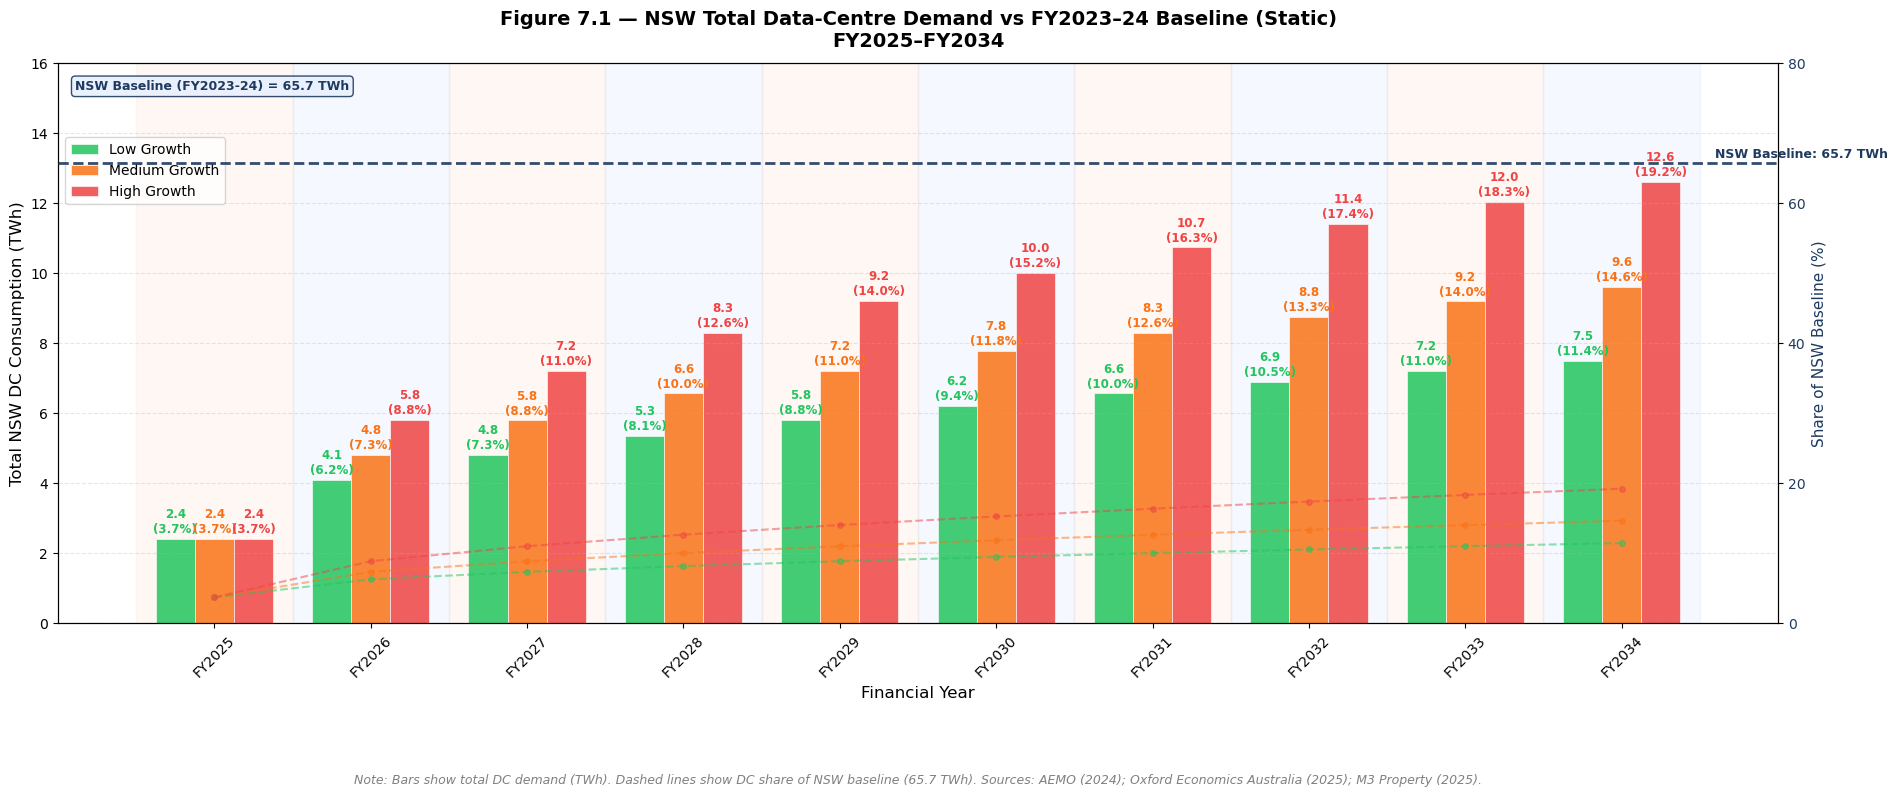

In [25]:
# ── FIGURE 7.1 — Static baseline, clean dual axis ────────────────────────────
nsw_baseline_static = 65.7
years = list(range(2025, 2035))
x = np.arange(len(years))
width = 0.25

fig, ax1 = plt.subplots(figsize=(20, 8))

# Alternating shading
for i in range(0, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#f97316')
for i in range(1, len(years), 2):
    ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='#3b82f6')

# Scenario bars
for idx, (name, s) in enumerate(scenario_inputs.items()):
    offset = (idx - 1) * width
    bars = ax1.bar(x + offset, s['twh_series'],
                   width, color=s['color'], alpha=0.85,
                   label=name, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, s['twh_series']):
        pct = val / nsw_baseline_static * 100
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}\n({pct:.1f}%)',
                 ha='center', va='bottom',
                 fontsize=8.5, color=s['color'], fontweight='bold')

# Right axis — % of baseline
ax2 = ax1.twinx()
for idx, (name, s) in enumerate(scenario_inputs.items()):
    pct_series = [v / nsw_baseline_static * 100 for v in s['twh_series']]
    ax2.plot(x, pct_series, color=s['color'],
             linewidth=1.5, linestyle='--',
             marker='o', markersize=4, alpha=0.5)

# Left axis — DC demand scale (0-16 TWh)
ax1.set_ylim(0, 16)
ax1.set_yticks([0, 2, 4, 6, 8, 10, 12, 14, 16])
ax1.set_yticklabels(['0', '2', '4', '6', '8', '10', '12', '14', '16'], fontsize=10)
ax1.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)

# Right axis — baseline scale (0-80 TWh)
ax2.set_ylim(0, 80)
ax2.set_yticks([0, 20, 40, 60, 80])
ax2.set_yticklabels(['0', '20', '40', '60', '80'], fontsize=10, color='#1e3a5f')
ax2.set_ylabel('NSW Total Electricity Demand (TWh)', fontsize=11, color='#1e3a5f')
ax2.tick_params(axis='y', labelcolor='#1e3a5f')

# Add baseline line on RIGHT axis at 65.7
ax2.axhline(65.7, color='#1e3a5f', linestyle='--',
            linewidth=2, alpha=0.9, zorder=5)
ax2.text(9.6, 66.5, f'NSW Baseline: {nsw_baseline_static} TWh',
         fontsize=9, color='#1e3a5f', fontweight='bold')

# Baseline reference box
ax1.text(0.01, 0.97,
         f'NSW Baseline (FY2023-24) = {nsw_baseline_static} TWh',
         transform=ax1.transAxes,
         fontsize=9, color='#1e3a5f', fontweight='bold',
         va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f0fe',
                   edgecolor='#1e3a5f', alpha=0.9))

ax1.set_title('Figure 7.1 — NSW Total Data-Centre Demand vs FY2023–24 Baseline (Static)\nFY2025–FY2034',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Financial Year', fontsize=12)
ax1.set_ylabel('Total NSW DC Consumption (TWh)', fontsize=12)
ax2.set_ylabel('Share of NSW Baseline (%)', fontsize=11, color='#1e3a5f')
ax2.tick_params(axis='y', labelcolor='#1e3a5f')
ax1.set_xticks(x)
ax1.set_xticklabels([f'FY{y}' for y in years], rotation=45, fontsize=10)
ax1.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0, 0.88))
ax1.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.5, -0.02,
         f'Note: Bars show total DC demand (TWh). Dashed lines show DC share of NSW baseline ({nsw_baseline_static} TWh). '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=9, style='italic', color='grey')

plt.subplots_adjust(left=0.07, right=0.93, bottom=0.18, top=0.88)
plt.show()

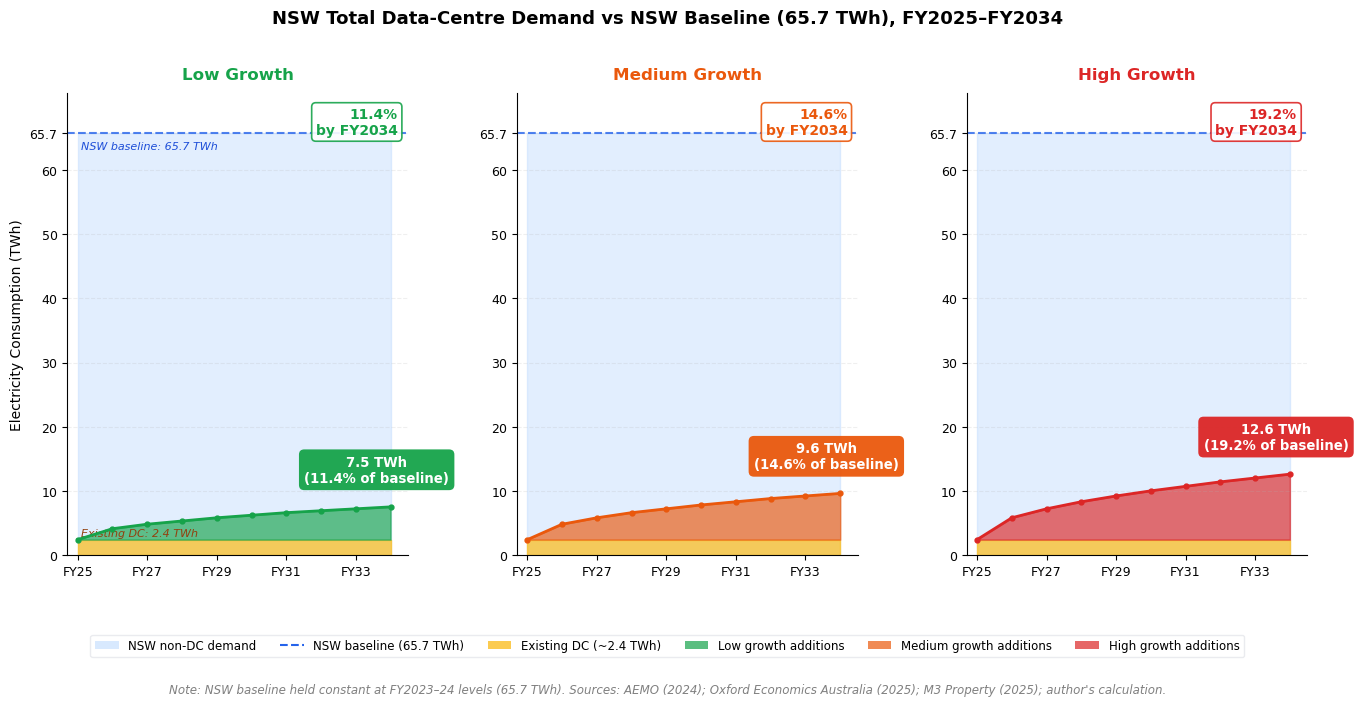

In [43]:
# ── FIGURE 7 — Small Multiples (polished) ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

nsw_baseline = 65.7
years = list(range(2025, 2035))
existing_dc = 2.4

def ramp_up(final_value, n_years=10):
    x = np.linspace(0, 1, n_years)
    return np.round(final_value * np.sqrt(x), 2)

scenarios = {
    'Low Growth':    {'final_twh': 5.1,  'color': '#16a34a'},
    'Medium Growth': {'final_twh': 7.2,  'color': '#ea580c'},
    'High Growth':   {'final_twh': 10.2, 'color': '#dc2626'},
}

for name, s in scenarios.items():
    s['total_series'] = [round(existing_dc + t, 1) for t in ramp_up(s['final_twh'])]

fig = plt.figure(figsize=(16, 6))
fig.suptitle('NSW Total Data-Centre Demand vs NSW Baseline (65.7 TWh), FY2025–FY2034',
             fontsize=13, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

for idx, (name, s) in enumerate(scenarios.items()):
    ax = fig.add_subplot(gs[idx])

    # NSW non-DC background fill
    ax.fill_between(years, nsw_baseline, color='#bfdbfe', alpha=0.45)

    # NSW baseline dashed line
    ax.axhline(nsw_baseline, color='#2563eb', linestyle='--',
               linewidth=1.5, alpha=0.8)

    # Existing DC (yellow base)
    ax.fill_between(years, existing_dc, color='#fbbf24', alpha=0.75)

    # New DC additions (scenario colour)
    ax.fill_between(years, s['total_series'], existing_dc,
                    color=s['color'], alpha=0.65)
    ax.plot(years, s['total_series'], color=s['color'],
            linewidth=2, marker='o', markersize=3.5, zorder=5)

    # ── Annotate FY2034 endpoint ──────────────────────────────────────────────
    final_val = s['total_series'][-1]
    final_pct = round(final_val / nsw_baseline * 100, 1)
    ax.annotate(f'{final_val} TWh\n({final_pct}% of baseline)',
                xy=(2034, final_val),
                xytext=(-10, 18), textcoords='offset points',
                fontsize=9.5, color='white', fontweight='bold',
                ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=s['color'],
                          edgecolor='none', alpha=0.95))

    # ── Annotate NSW baseline (first panel only) ──────────────────────────────
    if idx == 0:
        ax.text(2025.1, nsw_baseline - 2.5,
                f'NSW baseline: {nsw_baseline} TWh',
                fontsize=8, color='#1d4ed8', style='italic')

    # ── Annotate existing DC (first panel only) ───────────────────────────────
    if idx == 0:
        ax.text(2025.1, existing_dc + 0.6,
                f'Existing DC: {existing_dc} TWh',
                fontsize=8, color='#92400e', style='italic')

    # ── % share label top-right ───────────────────────────────────────────────
    ax.text(0.97, 0.97, f'{final_pct}%\nby FY2034',
            transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=s['color'],
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=s['color'], alpha=0.9, linewidth=1.2))

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(name, fontsize=12, fontweight='bold',
                 color=s['color'], pad=10)
    ax.set_ylim(0, 72)
    ax.set_xlim(2024.7, 2034.5)
    ax.set_xticks([2025, 2027, 2029, 2031, 2033])
    ax.set_xticklabels(['FY25', 'FY27', 'FY29', 'FY31', 'FY33'], fontsize=9)
    ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 65.7])
    ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '65.7'],
                       fontsize=9)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if idx == 0:
        ax.set_ylabel('Electricity Consumption (TWh)', fontsize=10)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor='#bfdbfe', alpha=0.6, label='NSW non-DC demand'),
    Line2D([0], [0], color='#2563eb', linestyle='--',
           linewidth=1.5, label=f'NSW baseline ({nsw_baseline} TWh)'),
    Patch(facecolor='#fbbf24', alpha=0.8, label='Existing DC (~2.4 TWh)'),
    Patch(facecolor='#16a34a', alpha=0.7, label='Low growth additions'),
    Patch(facecolor='#ea580c', alpha=0.7, label='Medium growth additions'),
    Patch(facecolor='#dc2626', alpha=0.7, label='High growth additions'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.07),
           frameon=True, edgecolor='#e5e7eb')

fig.text(0.5, -0.12,
         'Note: NSW baseline held constant at FY2023–24 levels (65.7 TWh). '
         'Sources: AEMO (2024); Oxford Economics Australia (2025); '
         'M3 Property (2025); author\'s calculation.',
         ha='center', fontsize=8.5, style='italic', color='grey')
plt.show()

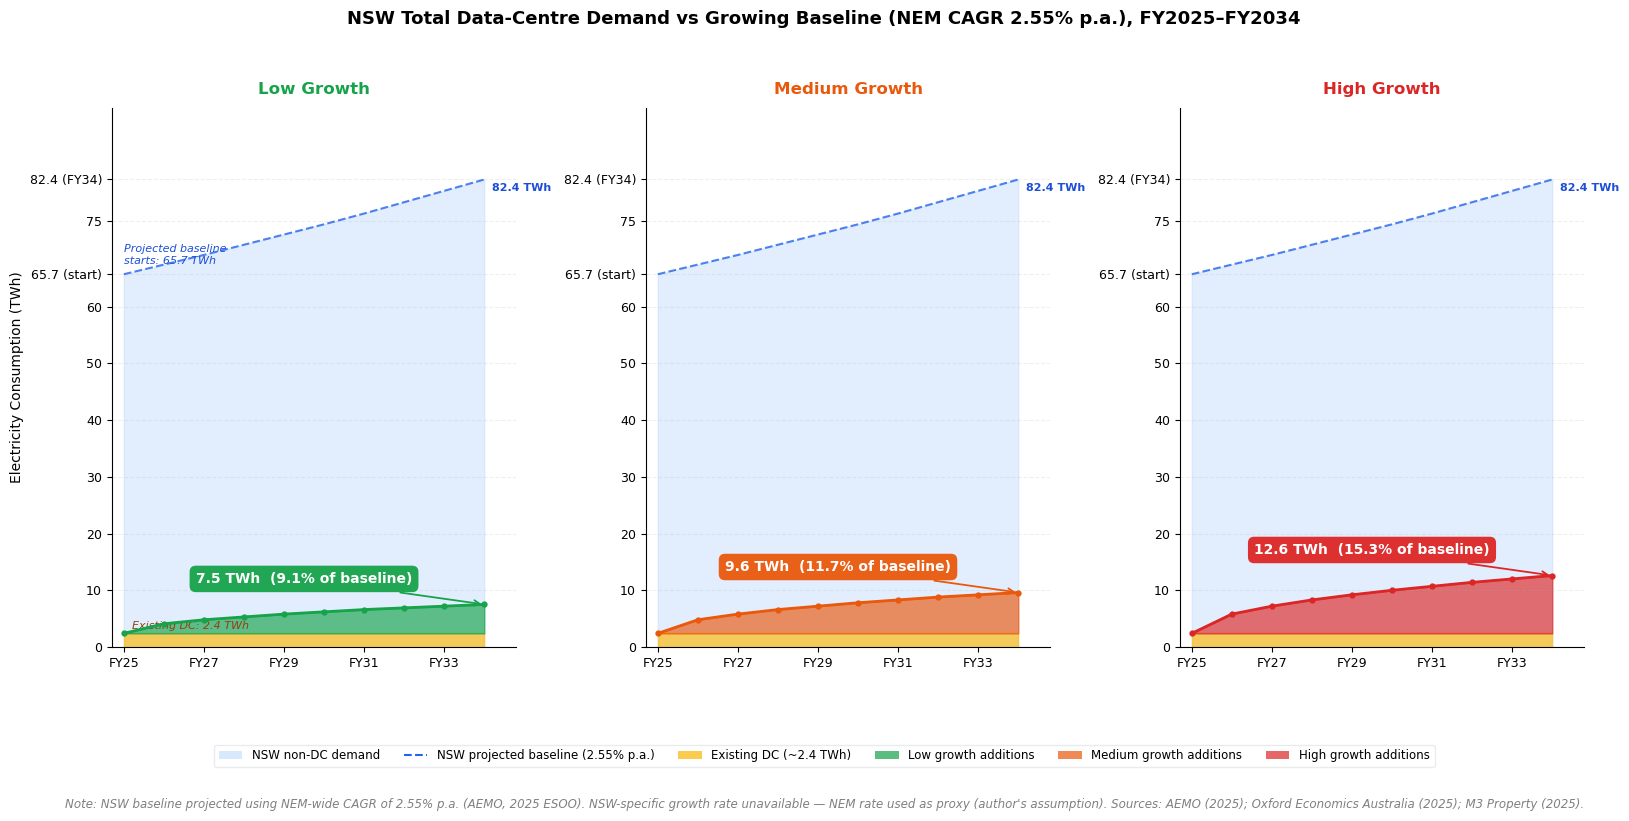

In [42]:
# ── FIGURE 7.2 — Small Multiples, Growing Baseline (final) ───────────────────
all_years        = list(range(2025, 2035))
existing_dc      = 2.4
nem_growth       = 0.0255
baseline_static  = 65.7
baseline_growing = [round(baseline_static * (1 + nem_growth) ** (y - 2025), 1)
                    for y in all_years]

def ramp_up(final_value, n_years=10):
    x = np.linspace(0, 1, n_years)
    return np.round(final_value * np.sqrt(x), 2)

scenarios = {
    'Low Growth':    {'final_twh': 5.1,  'color': '#16a34a'},
    'Medium Growth': {'final_twh': 7.2,  'color': '#ea580c'},
    'High Growth':   {'final_twh': 10.2, 'color': '#dc2626'},
}

for name, s in scenarios.items():
    s['total_series'] = [round(existing_dc + t, 1) for t in ramp_up(s['final_twh'])]

fig = plt.figure(figsize=(19, 7))
fig.suptitle('NSW Total Data-Centre Demand vs Growing Baseline '
             '(NEM CAGR 2.55% p.a.), FY2025–FY2034',
             fontsize=13, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

for idx, (name, s) in enumerate(scenarios.items()):
    ax = fig.add_subplot(gs[idx])

    # NSW non-DC background fill
    ax.fill_between(all_years, baseline_growing, color='#bfdbfe', alpha=0.45)

    # NSW growing baseline dashed line
    ax.plot(all_years, baseline_growing, color='#2563eb', linestyle='--',
            linewidth=1.5, alpha=0.8)

    # Existing DC yellow base
    ax.fill_between(all_years, existing_dc, color='#fbbf24', alpha=0.75)

    # New DC additions
    ax.fill_between(all_years, s['total_series'], existing_dc,
                    color=s['color'], alpha=0.65)
    ax.plot(all_years, s['total_series'], color=s['color'],
            linewidth=2, marker='o', markersize=3.5, zorder=5)

    final_val  = s['total_series'][-1]
    final_base = baseline_growing[-1]
    final_pct  = round(final_val / final_base * 100, 1)

    # ── Single clean endpoint tag ─────────────────────────────────────────────
    ax.annotate(f'{final_val} TWh  ({final_pct}% of baseline)',
                xy=(2034, final_val),
                xytext=(2029.5, final_val + 4.5),
                fontsize=10, color='white', fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.45', facecolor=s['color'],
                          edgecolor='none', alpha=0.95),
                arrowprops=dict(arrowstyle='->', color=s['color'],
                                lw=1.3, connectionstyle='arc3,rad=0.0'))

    # ── Baseline endpoint — right edge, nudged down to avoid tick clash ───────
    ax.text(2034.2, final_base - 1.5,
            f'{final_base} TWh',
            fontsize=8, color='#1d4ed8', fontweight='bold',
            ha='left', va='center', clip_on=False)

    # ── Baseline start label — first panel only ───────────────────────────────
    if idx == 0:
        ax.text(2025, baseline_growing[0] + 1.5,
                f'Projected baseline\nstarts: {baseline_static} TWh',
                fontsize=8, color='#1d4ed8', style='italic',
                va='bottom', ha='left')

    # ── Existing DC label — first panel only ──────────────────────────────────
    if idx == 0:
        ax.text(2025.2, existing_dc + 0.5,
                f'Existing DC: {existing_dc} TWh',
                fontsize=8, color='#92400e', style='italic',
                va='bottom', ha='left')

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(name, fontsize=12, fontweight='bold',
                 color=s['color'], pad=10)
    ax.set_ylim(0, 95)
    ax.set_xlim(2024.7, 2034.8)
    ax.set_xticks([2025, 2027, 2029, 2031, 2033])
    ax.set_xticklabels(['FY25', 'FY27', 'FY29', 'FY31', 'FY33'], fontsize=9)
    ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 65.7, 75, 82.4])
    ax.set_yticklabels(['0', '10', '20', '30', '40', '50', '60',
                        '65.7 (start)', '75', '82.4 (FY34)'],
                       fontsize=9)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if idx == 0:
        ax.set_ylabel('Electricity Consumption (TWh)', fontsize=10)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor='#bfdbfe', alpha=0.6, label='NSW non-DC demand'),
    Line2D([0], [0], color='#2563eb', linestyle='--',
           linewidth=1.5, label='NSW projected baseline (2.55% p.a.)'),
    Patch(facecolor='#fbbf24', alpha=0.8, label='Existing DC (~2.4 TWh)'),
    Patch(facecolor='#16a34a', alpha=0.7, label='Low growth additions'),
    Patch(facecolor='#ea580c', alpha=0.7, label='Medium growth additions'),
    Patch(facecolor='#dc2626', alpha=0.7, label='High growth additions'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.07),
           frameon=True, edgecolor='#e5e7eb')

fig.text(0.5, -0.12,
         'Note: NSW baseline projected using NEM-wide CAGR of 2.55% p.a. (AEMO, 2025 ESOO). '
         'NSW-specific growth rate unavailable — NEM rate used as proxy (author\'s assumption). '
         'Sources: AEMO (2025); Oxford Economics Australia (2025); M3 Property (2025).',
         ha='center', fontsize=8.5, style='italic', color='grey')
plt.show()